# 실시간 인플레이션 예측

In [1]:
import pandas as pd
from pandas.tseries.offsets import MonthEnd
from pandas.tseries.offsets import DateOffset

from inf import * # * : 모듈 전체 가져오기

import numpy as np

import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

import joblib

from sklearn.ensemble import ExtraTreesRegressor as EXT

import glob
import os

from tqdm import tqdm
import itertools

from tqdm import notebook
import pickle
idx = pd.IndexSlice

# 빈티지 데이터셋 불러오기 

In [2]:
vintages = pd.date_range('2012-12-02', '2025-06-27', freq='W-FRI')
targets = pd.date_range('2025-01-31', '2025-05-31', freq='M')

In [3]:
DF_vintages = {}

for date in vintages:
    df = pd.read_csv(f'vintages/{date:%Y-%m-%d}.csv', index_col=0)
    df.index = pd.DatetimeIndex(df.index, freq='M')
    DF_vintages[date] = df

# 하이퍼 파라미터 튜닝, 표본외 예측력 평가(Walk-forward Validation)

## Random Walk

In [4]:
p_results = pd.DataFrame(index=vintages)

for hor in [0, 3, 12]: # forecasting horizon
    print('\nh =', hor, end='\n')
    
    tms = tqdm(targets, desc=f'target month = ', dynamic_ncols=True)
    for tm in tms:
        tms.set_description(f'target month = {tm.strftime("%Y-%m")}')

        dates, _, _ = get_forecasting_dates(hor, tm, vintages)
        res = pd.DataFrame(index=dates, columns=[tm])
        
        for date in dates:
            _, y = get_train_data_v5(DF_vintages[date])
            y = y.shift(-hor)
            res.loc[date] = y.dropna().iloc[-1]

        res = pd.concat([res], axis=1, keys=[hor])
        p_results = pd.concat([p_results, res], axis=1)

p_results.columns = pd.MultiIndex.from_tuples(p_results.columns)
p_results = p_results.sort_index(axis=1)

fn = f'rw.pkl'  # 매월 모형추정
fol = 'output'
fp = os.path.join(fol, fn)
with open(fp, 'wb') as f:
    pickle.dump(p_results, f)


h = 0


target month = 2025-05: 100%|██████████| 5/5 [00:03<00:00,  1.31it/s]



h = 3


target month = 2025-05: 100%|██████████| 5/5 [00:06<00:00,  1.24s/it]



h = 12


target month = 2025-05: 100%|██████████| 5/5 [00:06<00:00,  1.25s/it]


## ARIMA

In [22]:
# Warning 무시
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

In [23]:
#for p, q, r in tqdm(itertools.product([2, 3], [1, 2], [2, 3])):
for p, q, r in tqdm(itertools.product([3], [1], [3])):

    print('\np, q, r: ', [p, q, r])

    p_results = pd.DataFrame(index=vintages)

    for hor in [0, 3, 12]: # forecasting horizon
        print('\nh = ', hor, end='\n')

        tms = tqdm(targets, desc=f'target month = ', dynamic_ncols=True)
        for tm in tms:
            tms.set_description(f'target month = {tm.strftime("%Y-%m")}')
            
            dates, _, _ = get_forecasting_dates(hor, tm, vintages) # 예측시계별로 타겟월에 대한 첫 예측 빈티지 시점부터 마지막 빈티지 시점까지 반환

            res = pd.DataFrame(index=dates, columns=[tm])
            for date in dates:

                _, y = get_train_data_v5(DF_vintages[date])

                y = y.shift(-hor) # 예측시계에 맞춰 시계열 조정
                arima = sm.tsa.arima.ARIMA(y, order=(p, q, r))
                fitted = arima.fit()
                predicted = fitted.predict(end = tm).iloc[-1]
                res.loc[date] = predicted

            res = pd.concat([res], axis=1, keys=[hor]) # keys=[hor]는 예측시계별로 데이터를 구분
            p_results = pd.concat([p_results, res], axis=1)

    p_results.columns = pd.MultiIndex.from_tuples(p_results.columns) # 예측시계와 타겟월을 멀터 인덱스로 구분
    p_results = p_results.sort_index(axis=1) # 예측시계별로 정렬

    fn = f'arima_p{p}_q{q}_r{r}.pkl'
    fol = 'output'
    fp = os.path.join(fol, fn)
    with open(fp, 'wb') as f:
        pickle.dump(p_results, f) # 예측결과를 파일로 저장

0it [00:00, ?it/s]


p, q, r:  [3, 1, 3]

h =  0


target month = 2025-05: 100%|██████████| 5/5 [00:45<00:00,  9.01s/it]



h =  3


target month = 2025-05: 100%|██████████| 5/5 [01:30<00:00, 18.18s/it]



h =  12


target month = 2025-05: 100%|██████████| 5/5 [01:30<00:00, 18.02s/it]
1it [03:46, 226.05s/it]


## Regression

In [24]:
lm_var0 = ['P_cpi_1', 'GB_cp_3'] # 고정변수
#lm_var1 = ['P_ipi_1', 'P_ipi_2', 'P_ipi_6', 'L_eap_10', 'C_rsi_1',
#           'C_css_1', 'IE_mir_9', 'RE_atpi_1', 'F_fb_1', 'P_adm', 'P_ppi_1']

#lm_var1 = ['P_ipi_6', 'RE_atpi_1', 'F_fb_1', 'P_adm', 'L_eap_10']
lm_var1 = ['P_ipi_6', 'RE_atpi_1'] # 고정변수에 추가로 조합할 변수

lm_models = []
for c in [1, 2]:
    lm_models += [list(i) + lm_var0 for i in itertools.combinations(lm_var1, c)]
# len(lm_models) = 66

In [25]:
lm_models

[['P_ipi_6', 'P_cpi_1', 'GB_cp_3'],
 ['RE_atpi_1', 'P_cpi_1', 'GB_cp_3'],
 ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'GB_cp_3']]

In [26]:
for model, lag, rolling in tqdm(itertools.product(lm_models, [3, 4, 6], [0])):

    print('\nmodel, lag, rolling: ', [model, lag, rolling])
    model_name = '-'.join(model)

    p_results = pd.DataFrame(index=vintages)

    for hor in [0, 3, 12]: # forecasting horizon
        print('\nh:', hor, end = '\n')
        
        for tm in targets:            
            if tm.month == 1:
                print(tm.strftime('%Y-%m'), end=' ')
            else:
               print(tm.strftime('%m'), end=' ')

            dates, _, m1 = get_forecasting_dates(hor, tm, vintages)
            res = pd.DataFrame(index=dates, columns=[tm])
            
            for date in dates:

                X_train, y_train = get_train_data_v5(DF_vintages[date], lag=lag, data_group=3, m1=m1, rolling=rolling, predictors=model)
                eqn = 'y ~ 1 + ' + ' + '.join(X_train.columns.tolist())

                #if tm.month in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:  # 타겟월이 매분기 첫째월인 경우만 모형 추정
                if tm.month in [1]:        # 타겟월이 1월인 경우만 모형 추정
                    y_train = y_train.shift(-hor).to_frame('y')
                    Xy_train = pd.concat([X_train, y_train], axis=1).dropna(axis=0)
                    reg = smf.ols(eqn, data = Xy_train).fit()
                    joblib.dump(reg, f"model/lm_roll{rolling}_lag{lag}_model{model_name}_{tm.year}-01_h{hor}.pkl")

                predictor = X_train.loc[[m1]]
                predicted = reg.predict(predictor)[0]
                res.loc[date] = predicted

            res = pd.concat([res], axis=1, keys=[hor])
            p_results = pd.concat([p_results, res], axis=1)

    p_results.columns = pd.MultiIndex.from_tuples(p_results.columns)
    p_results = p_results.sort_index(axis=1)

    fn = f'lm_roll{rolling}_lag{lag}_model{model_name}_IN.pkl' 
    fol = 'output'
    fp = os.path.join(fol, fn)
    with open(fp, 'wb') as f:
        pickle.dump(p_results, f)

0it [00:00, ?it/s]


model, lag, rolling:  [['P_ipi_6', 'P_cpi_1', 'GB_cp_3'], 3, 0]

h: 0
2025-01 02 03 04 05 
h: 3
2025-01 02 03 04 05 
h: 12
2025-01 02 03 04 05 

1it [00:21, 21.09s/it]


model, lag, rolling:  [['P_ipi_6', 'P_cpi_1', 'GB_cp_3'], 4, 0]

h: 0
2025-01 02 03 04 05 
h: 3
2025-01 02 03 04 05 
h: 12
2025-01 02 03 04 05 

2it [00:43, 21.61s/it]

...

7it [02:29, 21.36s/it]


model, lag, rolling:  [['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'GB_cp_3'], 4, 0]

h: 0
2025-01 02 03 04 05 
h: 3
2025-01 02 03 04 05 
h: 12
2025-01 02 03 04 05 

8it [02:51, 21.60s/it]


model, lag, rolling:  [['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'GB_cp_3'], 6, 0]

h: 0
2025-01 02 03 04 05 
h: 3
2025-01 02 03 04 05 
h: 12
2025-01 02 03 04 05 

9it [03:15, 21.78s/it]


## Extremely Randomized Tree(EXT)

In [29]:
#for rolling, lag, md, dn in notebook.tqdm(itertools.product([0], [0], [6, 8, 10], [1, 2])):
#for rolling, lag, md, dn in notebook.tqdm([[0, 0, 6, 1], [0, 0, 8, 1], [0, 0, 10, 1], [0, 0, 8, 2], [0, 0, 10, 2]]):
for rolling, lag, md, dn in notebook.tqdm([[0, 0, 6, 1]]):

    print('\nrolling, lag, md, dn: ', [rolling, lag, md, dn])
    model = EXT(n_estimators=2000, max_features=0.5, max_depth=md, n_jobs=-1) # random_state=0, max_features=1.0

    p_results = pd.DataFrame(index=vintages)

    for hor in [0, 3, 12]:
        print('\nh = ', hor, end = '\n')

        for tm in targets:

            if tm.month == 1:
                print(tm.strftime('%Y-%m'), end=' ')
            else:
                print(tm.strftime('%m'), end=' ')
               
            dates, _, m1 = get_forecasting_dates(hor, tm, vintages)
            res = pd.DataFrame(index=dates, columns=[tm])
            
            for date in dates:

                X_train, y_train = get_train_data_v5(DF_vintages[date], lag=lag, data_group=dn, excl_alt=True, m1=m1, rolling=rolling)
                if hor == 12:
                    X_train = X_train.drop(['P_eir'], axis = 1) # 기대인플레 제외

                if tm.month in [1]:  # 타겟월이 매년 1월에만 모형 추정
                    if hor == 0:
                        y_train = y_train.shift(-hor) - y_train.shift(1) # 차분된 값을 타겟으로
                    else:
                        y_train = y_train.shift(-hor) - y_train.shift(0)
                    Xy_train = pd.concat([X_train, y_train], axis=1).dropna(axis=0)
                    model.fit(Xy_train.iloc[:-1, :-1], Xy_train.iloc[:-1, -1])
                    #model.fit(Xy_train.iloc[:, :-1], Xy_train.iloc[:, -1])
                    joblib.dump(model, f"model/ext_roll{rolling}_lag{lag}_d{md}_g{dn}_{tm.year}-01_h{hor}.pkl")

                #_, y = get_train_data(vintages[-1], 0, 0, 0)
                _, y = get_train_data_v5(DF_vintages[vintages[-1]])

                predictor = X_train.loc[[m1]]
                if hor == 0:
                    res.loc[date] = model.predict(predictor) + y.loc[m1 - MonthEnd(1)]
                else:
                    res.loc[date] = model.predict(predictor) + y.loc[m1 - MonthEnd(0)]

            res = pd.concat([res], axis=1, keys=[hor])
            p_results = pd.concat([p_results, res], axis=1)

    p_results.columns = pd.MultiIndex.from_tuples(p_results.columns)
    p_results = p_results.sort_index(axis=1)

    fn = f'ext_roll{rolling}_lag{lag}_d{md}_g{dn}_IN.pkl'  # p1_diff : 1월에만 cpi 차이 예측
    fol = 'output'
    fp = os.path.join(fol, fn)
    with open(fp, 'wb') as f:
        pickle.dump(p_results, f)

  0%|          | 0/1 [00:00<?, ?it/s]


rolling, lag, md, dn:  [0, 0, 6, 1]

h =  0
2025-01 02 03 04 05 
h =  3
2025-01 02 03 04 05 
h =  12
2025-01 02 03 04 05 

# 모형별 예측치 읽어들이고, mae/rmse, last_pred 계산

In [30]:
# 과거 인플레이션 실제치
_, act = get_train_data_v5(DF_vintages[vintages[-1]])

## RW

In [31]:
# RW
rw_pred = pd.read_pickle('output/rw.pkl')

rw_mae = pd.DataFrame()
rw_rmse = pd.DataFrame()

err = get_error_by_vintage(rw_pred, act)
err, rw_mae, rw_rmse = align_error_by_week(err)
rw_pred_last = get_pred_last(rw_pred)

In [32]:
rw_pred[(0, '2025-01-31')].dropna()

2024-12-13    1.526447
2024-12-20    1.526447
2024-12-27    1.526447
2025-01-03    1.933824
2025-01-10    1.933824
2025-01-17    1.933824
2025-01-24    1.933824
2025-01-31    1.933824
Freq: W-FRI, Name: (0, 2025-01-31 00:00:00), dtype: object

In [33]:
rw_rmse.to_pickle('output/rw_rmse.pkl')
rw_mae.to_pickle('output/rw_mae.pkl')

## ARIMA

In [132]:
# ARIMA
files = glob.glob('output/arima_p3_q1_r3.pkl')
names = [file.split('/')[-1].split('.')[0] for file in files]

arima_pred = get_pred(files, names)
arima_mae, arima_rmse, arima_pred_last = get_eval_last_pred(arima_pred, names, act)

  0%|          | 0/1 [00:00<?, ?it/s]

In [133]:
arima_rmse.to_pickle('output/arima_rmse.pkl')
arima_mae.to_pickle('output/arima_mae.pkl')

## Reg

In [36]:
# lm_models = [['L_eap_10', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['F_fb_1', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['L_eap_10', 'RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['F_fb_1', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['L_eap_10', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['RE_atpi_1', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['P_ipi_6', 'L_eap_10', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#  ['IE_mir_9', 'RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3']]


In [37]:
# lm_models = [['RE_atpi_1', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#              ['F_fb_1', 'P_adm', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#              ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#              ['RE_atpi_1', 'P_cpi_1', 'P_eir', 'GB_cp_3'],
#              ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'P_eir' 'GB_cp_3'],
#              ['P_ipi_6', 'RE_atpi_1', 'P_cpi_1', 'GB_cp_3']]
             
lm_pred_files = [f'lm_roll0_lag{l}_model{m}_IN.pkl' for l in [3, 4, 6] for m in ['-'.join(model) for model in lm_models]]

files = glob.glob('output/lm_*')
files = [file for file in files if file.split('\\')[-1] in lm_pred_files]
names = [file.split('\\')[-1].split('.')[0] for file in files]

In [38]:
lm_pred = get_pred(files, names)
lm_mae, lm_rmse, lm_pred_last = get_eval_last_pred(lm_pred, names, act)

for df, data in zip([lm_pred, lm_mae, lm_rmse, lm_pred_last], ['pred', 'mae', 'rmse', 'pred_last']):
    df.to_pickle(f"output/lm_{data}.pkl")

  0%|          | 0/9 [00:00<?, ?it/s]

In [39]:
dfs = []

for res in ['pred', 'mae', 'rmse', 'pred_last']:
    df = pd.read_pickle(f"output/lm_{res}.pkl")
    dfs.append(df)

lm_pred = dfs[0]
lm_mae = dfs[1]
lm_rmse = dfs[2]
lm_pred_last = dfs[3]

## EXT

In [40]:
# EXT
files = glob.glob('output/ext_*')
names = [file.split('\\')[-1].split('.')[0] for file in files]

In [41]:
ext_pred = get_pred(files, names)
ext_mae, ext_rmse, ext_pred_last = get_eval_last_pred(ext_pred, names, act)

  0%|          | 0/1 [00:00<?, ?it/s]

## Ensemble(lm + ext)

In [42]:
lm_best_for_ensemble = []

for hor in [0]:
    lm_best_for_ensemble += lm_mae[hor].iloc[-1].sort_values().index[:10].tolist()
    lm_best_for_ensemble += lm_rmse[hor].iloc[-1].sort_values().index[:10].tolist()

lm_best_for_ensemble = list(set(lm_best_for_ensemble))
#len(lm_best_for_ensemble) = 10

In [43]:
lm_best_for_ensemble

['lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN']

In [44]:
# lm_best_for_ensemble = ['lm_roll0_lag6_modelRE_atpi_1:P_adm:P_cpi_1:P_eir:GB_cp_3',
#                         'lm_roll0_lag4_modelF_fb_1:P_adm:P_cpi_1:P_eir:GB_cp_3',
#                         'lm_roll0_lag6_modelP_ipi_6:RE_atpi_1:P_cpi_1:P_eir:GB_cp_3',
#                         'lm_roll0_lag3_modelRE_atpi_1:P_cpi_1:P_eir:GB_cp_3',
#                         'lm_roll0_lag4_modelP_ipi_6:RE_atpi_1:P_cpi_1:GB_cp_3']
# lm_best_for_ensemble

In [45]:
ext_best_for_ensemble = []

for hor in [0]:
    ext_best_for_ensemble += ext_mae[hor].iloc[-1].sort_values().index[:3].tolist()
    ext_best_for_ensemble += ext_rmse[hor].iloc[-1].sort_values().index[:3].tolist()

ext_best_for_ensemble = list(set(ext_best_for_ensemble))

In [272]:
ens_models = []
for c in [1, 2, 3]:
    ens_models += [list(i) for i in itertools.combinations(lm_best_for_ensemble, c)]

ens_models = [m + [n] for m in ens_models for n in ext_best_for_ensemble] #+ ens_models

In [273]:
ens_models

[['lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN', 'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN', 'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN', 'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'ext_roll0_lag0_d6_g1_IN'],
 ['lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
  'lm_roll0_lag4_modelRE_atp

In [50]:
#get_best_ens_models(ens_models)

In [51]:
#ens_models[18]

In [52]:
# models = ext_best_for_ensemble + lm_best_for_ensemble
# ens_models = []
# for c in [2, 3, len(models)]:
#    ens_models += [list(i) for i in itertools.combinations(models, c)]

In [53]:
hors = lm_pred.columns.get_level_values(1).unique().tolist()
target = lm_pred.columns.get_level_values(2).unique().tolist()

big_pred = pd.concat([lm_pred, ext_pred], axis=1)
ens_pred = pd.DataFrame()

for i, model in notebook.tqdm(enumerate(ens_models)):
    pred = big_pred[model]
    df = pd.DataFrame(0, index=vintages, columns=pd.MultiIndex.from_product([hors, targets]))
    for m in pred.columns.get_level_values(0).unique():
        df = df + pred[m]
    df = df / len(model)

    df = pd.concat([df], axis=1, keys=['ens' + str(i)])
    ens_pred = pd.concat([ens_pred, df], axis=1)

ens_pred.to_pickle("output/ens_pred.pkl")
ens_pred = ens_pred.sort_index(axis=1)
ens_mae, ens_rmse, ens_pred_last = get_eval_last_pred(ens_pred, ens_pred.columns.get_level_values(0).unique(), act)
# ens_pred.info()  566 X 325500, 1.4GB

for df, data in zip([ens_pred, ens_mae, ens_rmse, ens_pred_last], ['pred', 'mae', 'rmse', 'pred_last']):
    df.to_pickle(f"output/ens_{data}.pkl")

0it [00:00, ?it/s]

  0%|          | 0/129 [00:00<?, ?it/s]

In [54]:
ens_pred.columns.get_level_values(0).unique()

Index(['ens0', 'ens1', 'ens10', 'ens100', 'ens101', 'ens102', 'ens103',
       'ens104', 'ens105', 'ens106',
       ...
       'ens90', 'ens91', 'ens92', 'ens93', 'ens94', 'ens95', 'ens96', 'ens97',
       'ens98', 'ens99'],
      dtype='object', length=129)

In [55]:
dfs = []

for data in ['pred', 'mae', 'rmse', 'pred_last']:
    df = pd.read_pickle(f"output/ens_{data}.pkl")
    dfs.append(df)

ens_pred = dfs[0]
ens_mae = dfs[1]
ens_rmse = dfs[2]
ens_pred_last = dfs[3]

# 모든 전망시계, 모형별 Plot RMSE/MAE

In [60]:
ens_rmse = ens_rmse.iloc[1:,:]
ens_mae = ens_mae.iloc[1:,:]
lm_rmse = lm_rmse.iloc[1:,:]
lm_mae = lm_mae.iloc[1:,:]
ext_rmse = ext_rmse.iloc[1:,:]
ext_mae = ext_mae.iloc[1:,:]
arima_rmse = arima_rmse.iloc[1:,:]
arima_mae = arima_mae.iloc[1:,:]
rw_rmse = rw_rmse.iloc[1:,:]
rw_mae = rw_mae.iloc[1:,:]

In [ ]:
#from matplotlib.ticker import MultipleLocator

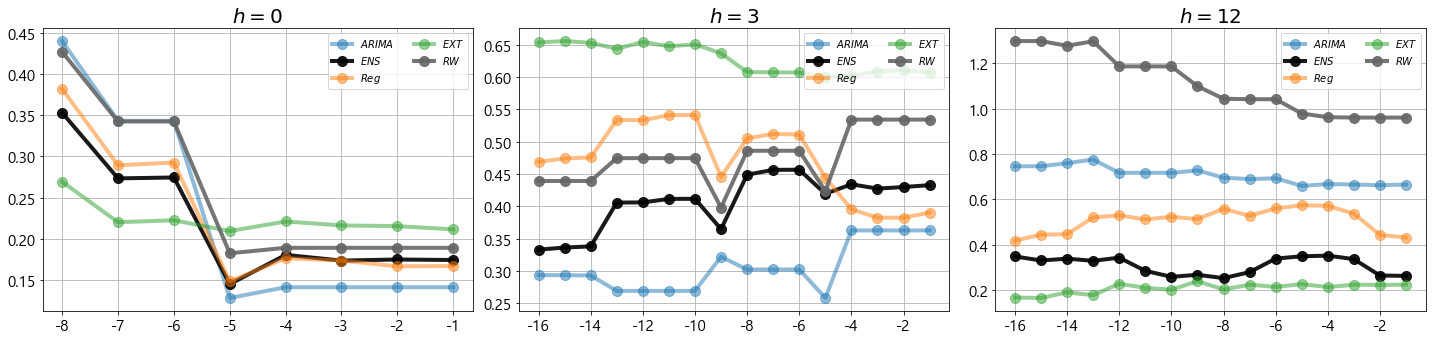

In [65]:
plot_rmse(arima_rmse, ens_rmse, lm_rmse,ext_rmse, rw_rmse, best=1, good=1, title='', ncol=2, loc='upper right', figsize=(20, 5), 
          bbox_to_anchor=(1, 1), fontsize=10)

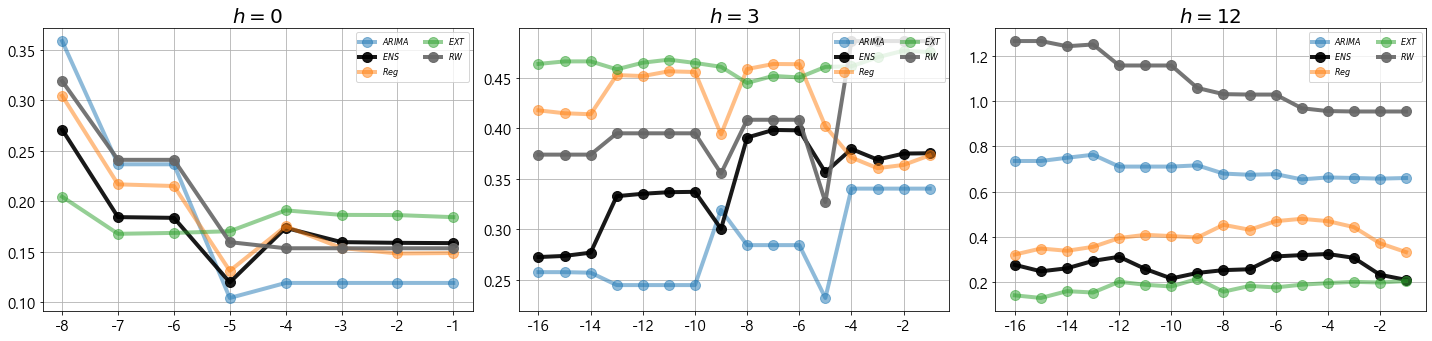

In [62]:
plot_mae(arima_mae, ens_mae, lm_mae, ext_mae, rw_mae, best=1, good=1, title='', ncol=2, loc='upper right', figsize=(20, 5), 
          bbox_to_anchor=(1, 1), fontsize=8)

# Plot MAE/RMSE

(MAE) arima_p3_q1_r3: 0.119 
(RMSE) arima_p3_q1_r3: 0.142 
rw: 0.154 

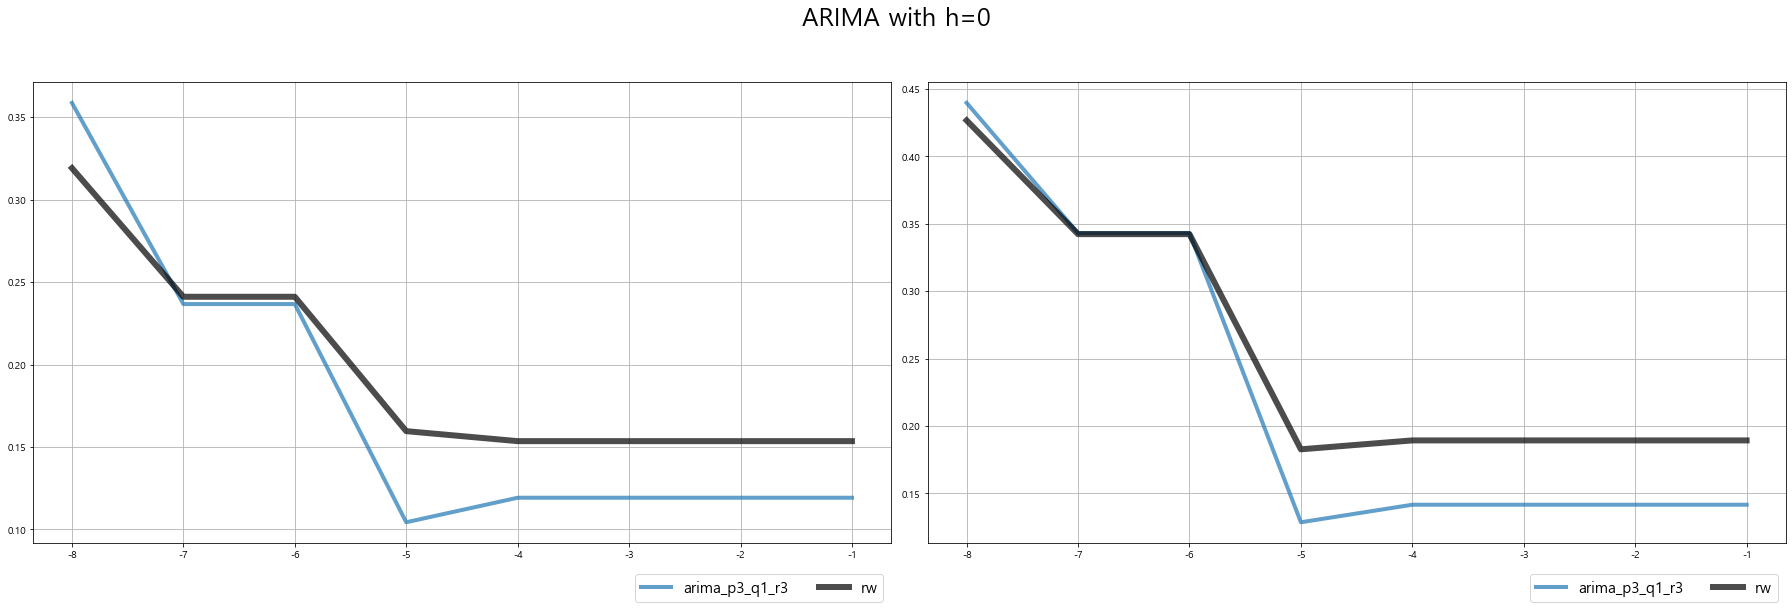

In [68]:
plot_mae_rmse(arima_mae, arima_rmse, rw_mae, rw_rmse, h=0, best=5, good=10, title='ARIMA',
              loc=1, ncol=4, figsize=(25, 8), fontsize=15, bbox_to_anchor=(1, -0.05))

(MAE) arima_p3_q1_r3: 0.340 
(RMSE) arima_p3_q1_r3: 0.363 
rw: 0.486 

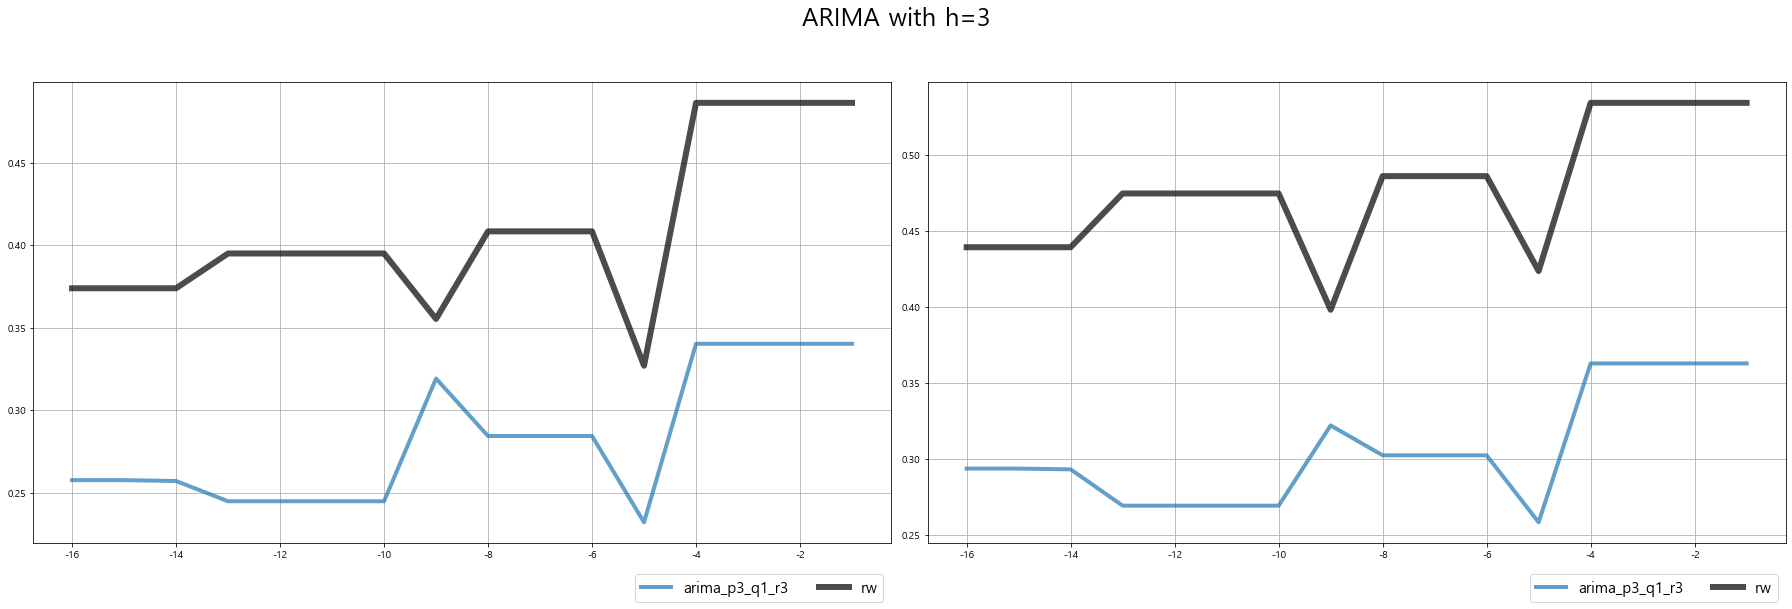

In [69]:
plot_mae_rmse(arima_mae, arima_rmse, rw_mae, rw_rmse, h=3, best=5, good=10, title='ARIMA',
              loc=1, ncol=4, figsize=(25, 8), fontsize=15, bbox_to_anchor=(1, -0.05))

(MAE) arima_p3_q1_r3: 0.660 
(RMSE) arima_p3_q1_r3: 0.665 
rw: 0.955 

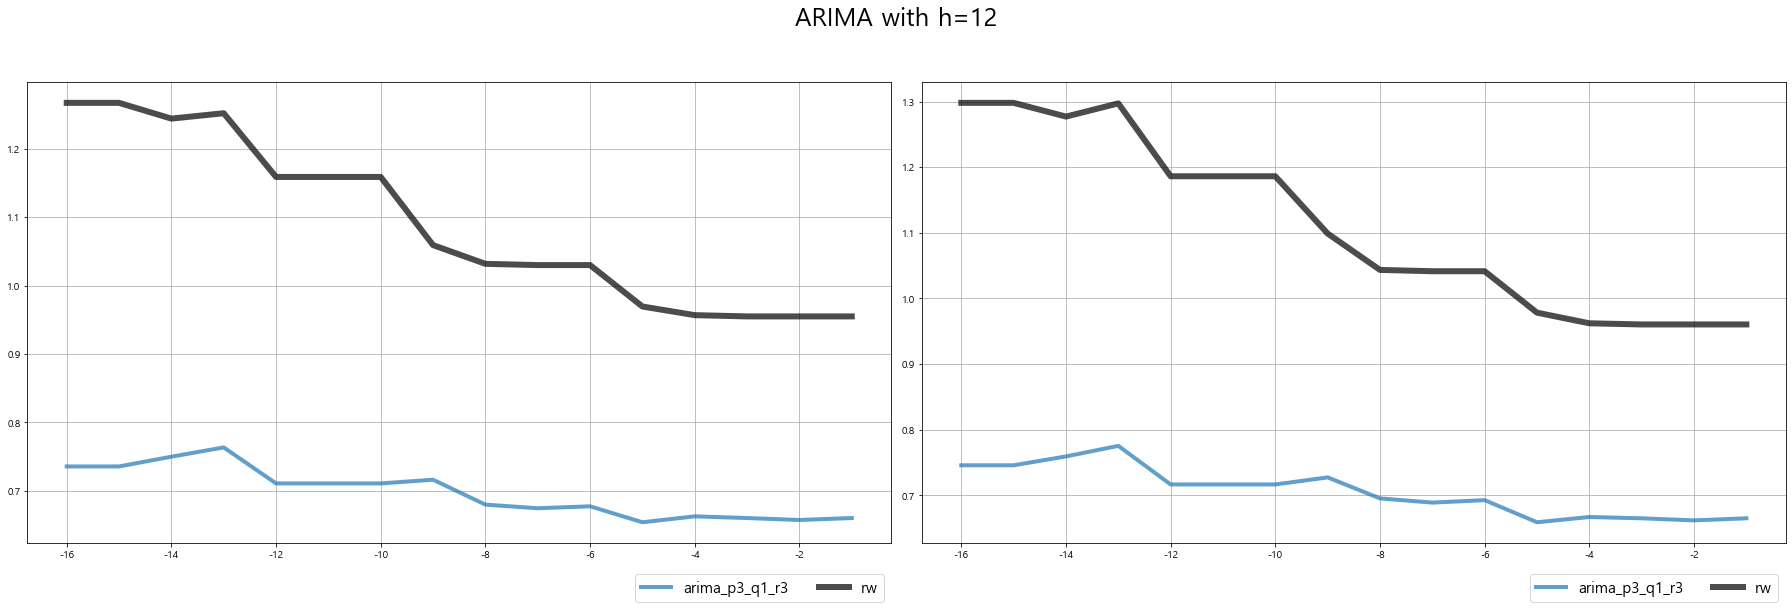

In [70]:
plot_mae_rmse(arima_mae, arima_rmse, rw_mae, rw_rmse, h=12, best=5, good=10, title='ARIMA',
              loc=1, ncol=4, figsize=(25, 8), fontsize=15, bbox_to_anchor=(1, -0.05))

## LM

(MAE) lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.149 lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.153 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.153 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.154 lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.154 
(RMSE) lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.167 lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.170 lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.170 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.178 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.178 
rw: 0.154 

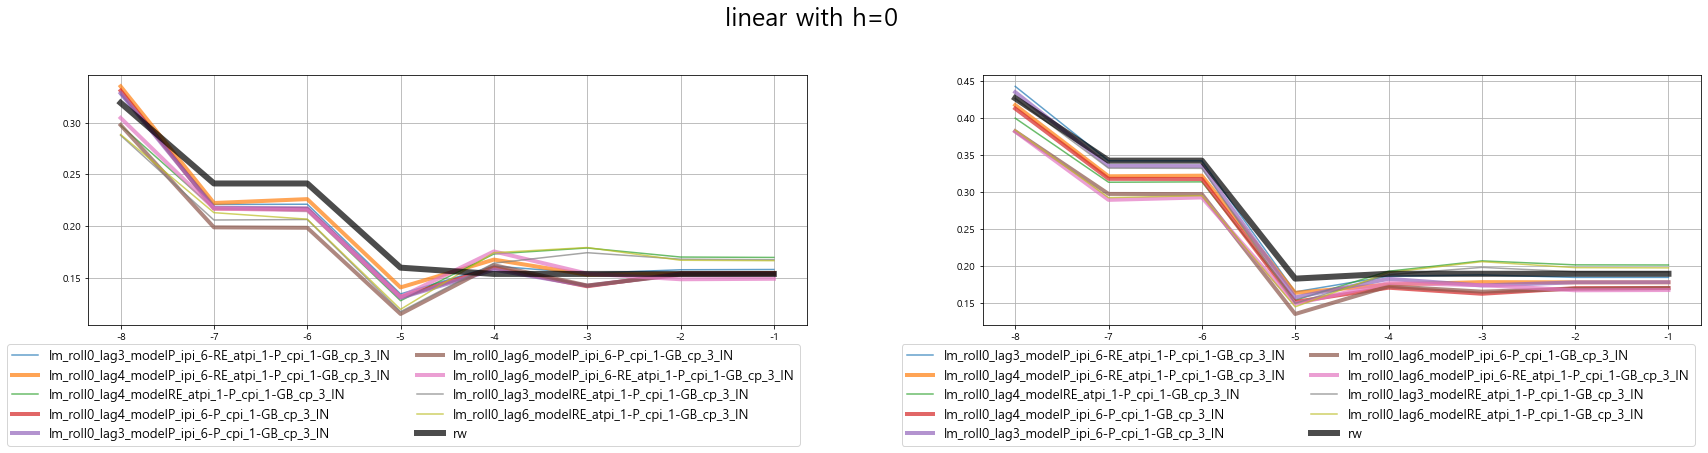

In [71]:
plot_mae_rmse(lm_mae, lm_rmse, rw_mae, rw_rmse, h=0, best=5, good=10, title='linear',
              loc=1, ncol=2, figsize=(25, 6), fontsize=13, bbox_to_anchor=(1, -0.05))

(MAE) lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.373 lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.377 lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.381 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.412 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.420 
(RMSE) lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.391 lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.400 lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.407 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN: 0.437 lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.455 
rw: 0.486 

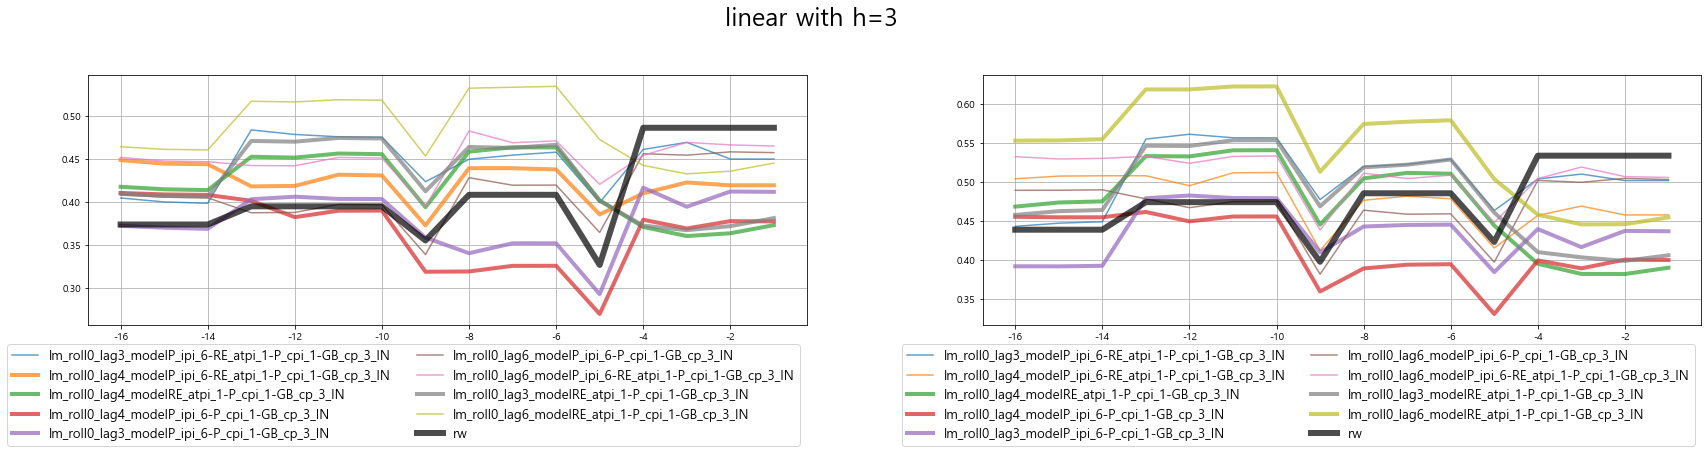

In [72]:
plot_mae_rmse(lm_mae, lm_rmse, rw_mae, rw_rmse, h=3, best=5, good=10, title='linear',
              loc=1, ncol=2, figsize=(25, 6), fontsize=13, bbox_to_anchor=(1, -0.05))

(MAE) lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.332 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.441 lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.492 lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.506 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.509 
(RMSE) lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.431 lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.515 lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.536 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.547 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN: 0.613 
rw: 0.955 

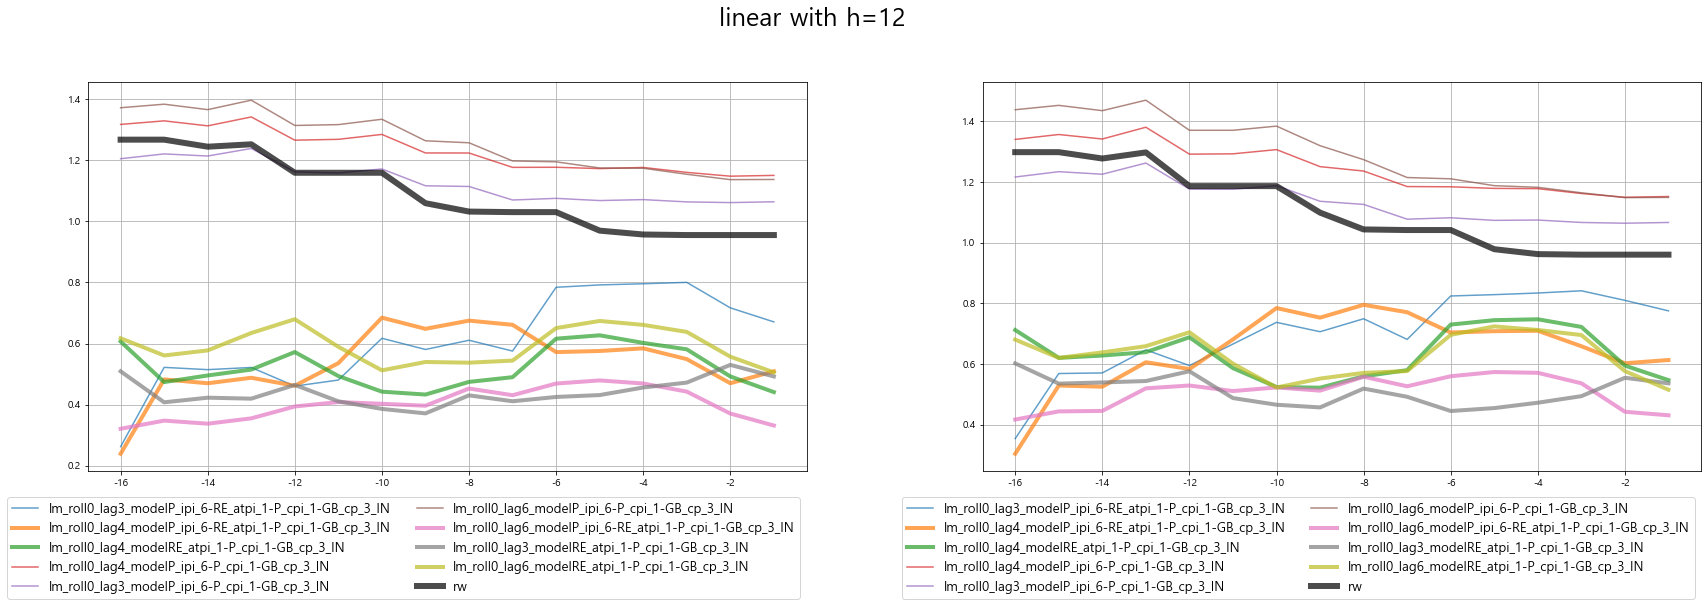

In [73]:
plot_mae_rmse(lm_mae, lm_rmse, rw_mae, rw_rmse, h=12, best=5, good=15, title='linear',
              loc=1, ncol=2, figsize=(25, 8), fontsize=13, bbox_to_anchor=(1, -0.05))

## EXT

(MAE) ext_roll0_lag0_d6_g1_IN: 0.184 
(RMSE) ext_roll0_lag0_d6_g1_IN: 0.212 
rw: 0.154 

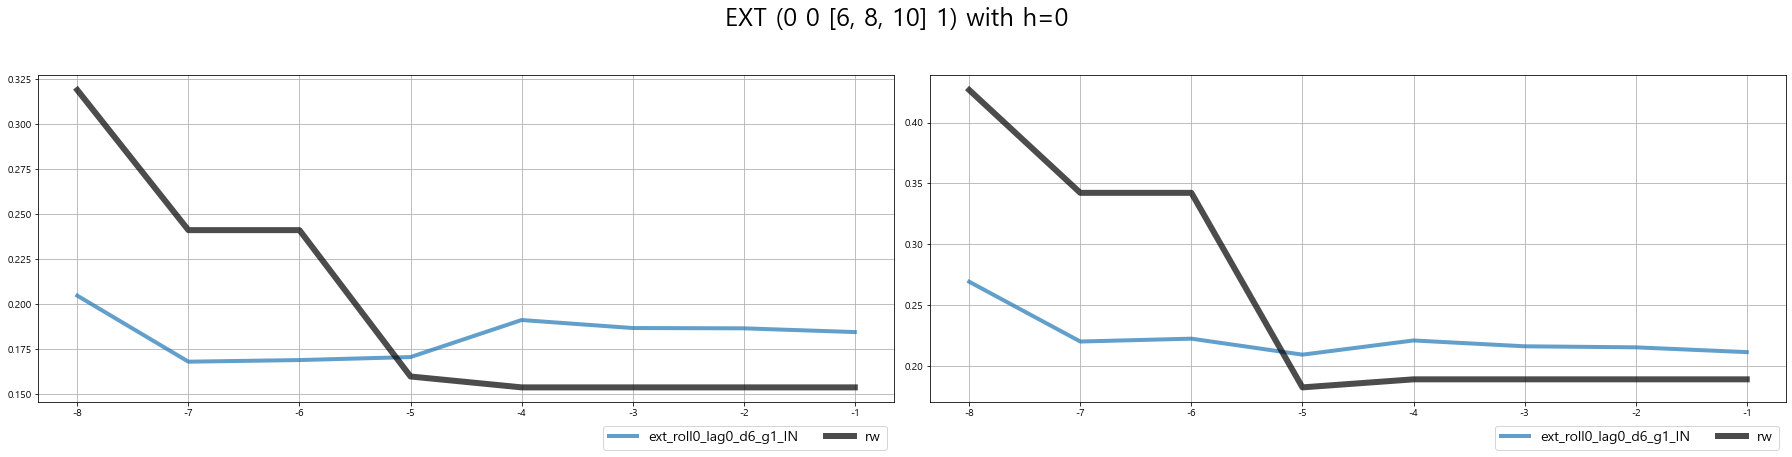

In [74]:
plot_mae_rmse(ext_mae, ext_rmse, rw_mae, rw_rmse, h=0, best=5, good=10, title='EXT (0 0 [6, 8, 10] 1)',
              loc=1, ncol=3, figsize=(25, 6), fontsize=14, bbox_to_anchor=(1, -0.05))

(MAE) ext_roll0_lag0_d6_g1_IN: 0.475 
(RMSE) ext_roll0_lag0_d6_g1_IN: 0.607 
rw: 0.486 

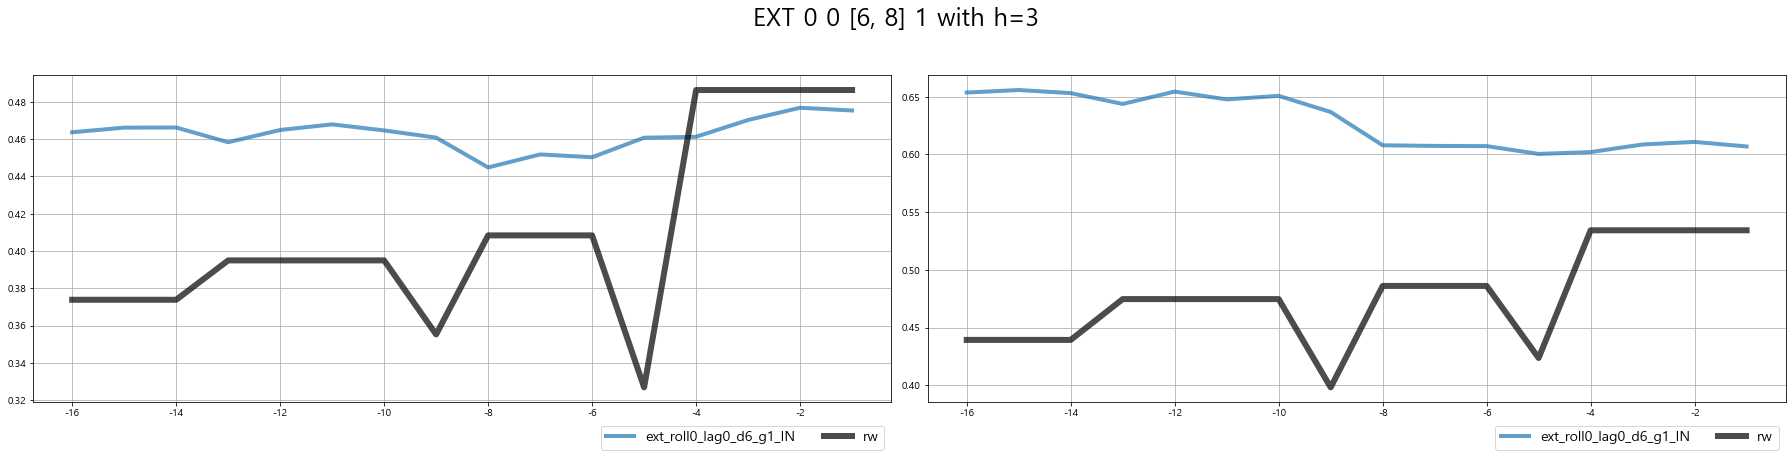

In [75]:
plot_mae_rmse(ext_mae, ext_rmse, rw_mae, rw_rmse, h=3, best=5, good=10, title='EXT 0 0 [6, 8] 1',
              loc=1, ncol=3, figsize=(25, 6), fontsize=14, bbox_to_anchor=(1, -0.05))

(MAE) ext_roll0_lag0_d6_g1_IN: 0.204 
(RMSE) ext_roll0_lag0_d6_g1_IN: 0.223 
rw: 0.955 

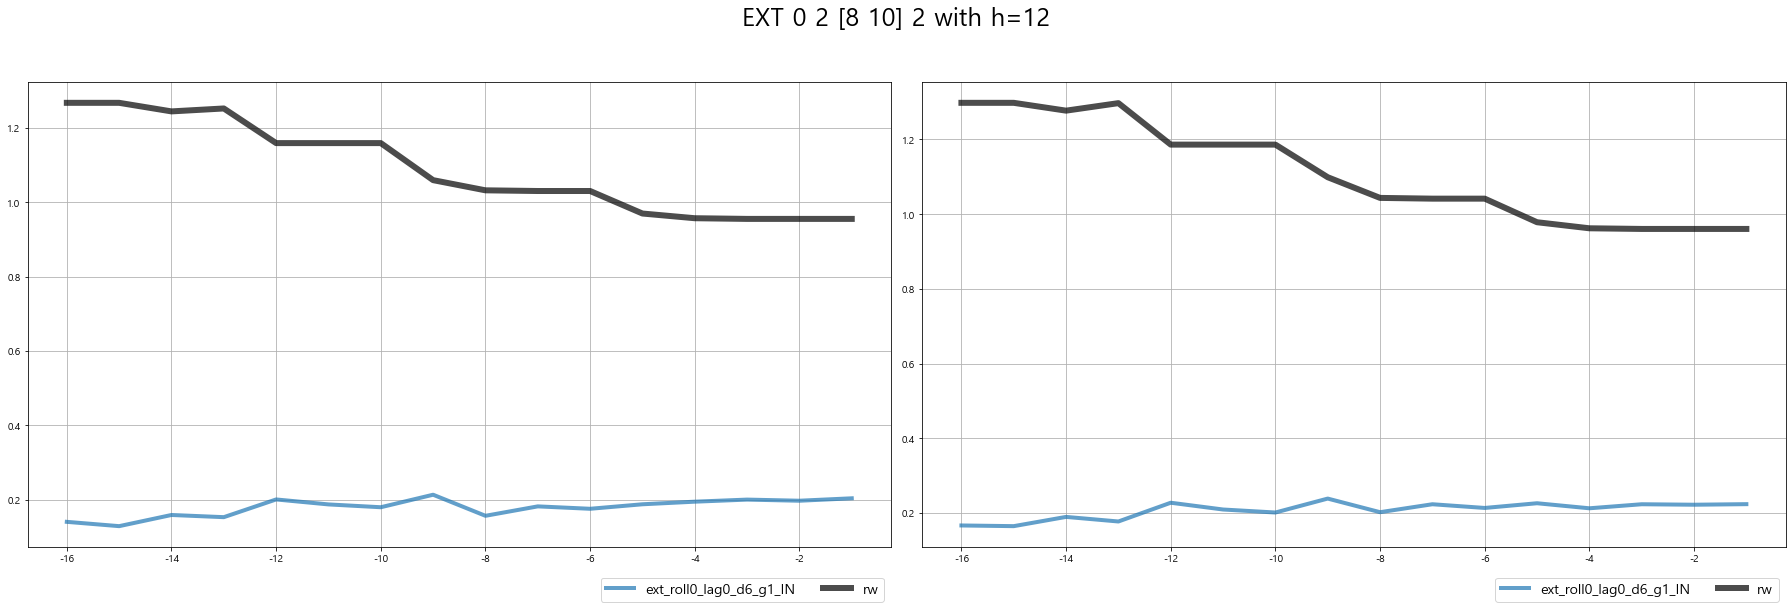

In [76]:
plot_mae_rmse(ext_mae, ext_rmse, rw_mae, rw_rmse, h=12, best=5, good=10, title='EXT 0 2 [8 10] 2',
              loc=1, ncol=3, figsize=(25, 8), fontsize=14, bbox_to_anchor=(1, -0.05))

## Ensemble

(MAE) ens49: 0.159 ens67: 0.159 ens64: 0.159 ens88: 0.159 ens85: 0.159 
(RMSE) ens113: 0.175 ens88: 0.176 ens119: 0.176 ens80: 0.177 ens39: 0.177 
rw mae: 0.154 rw rmse: 0.189


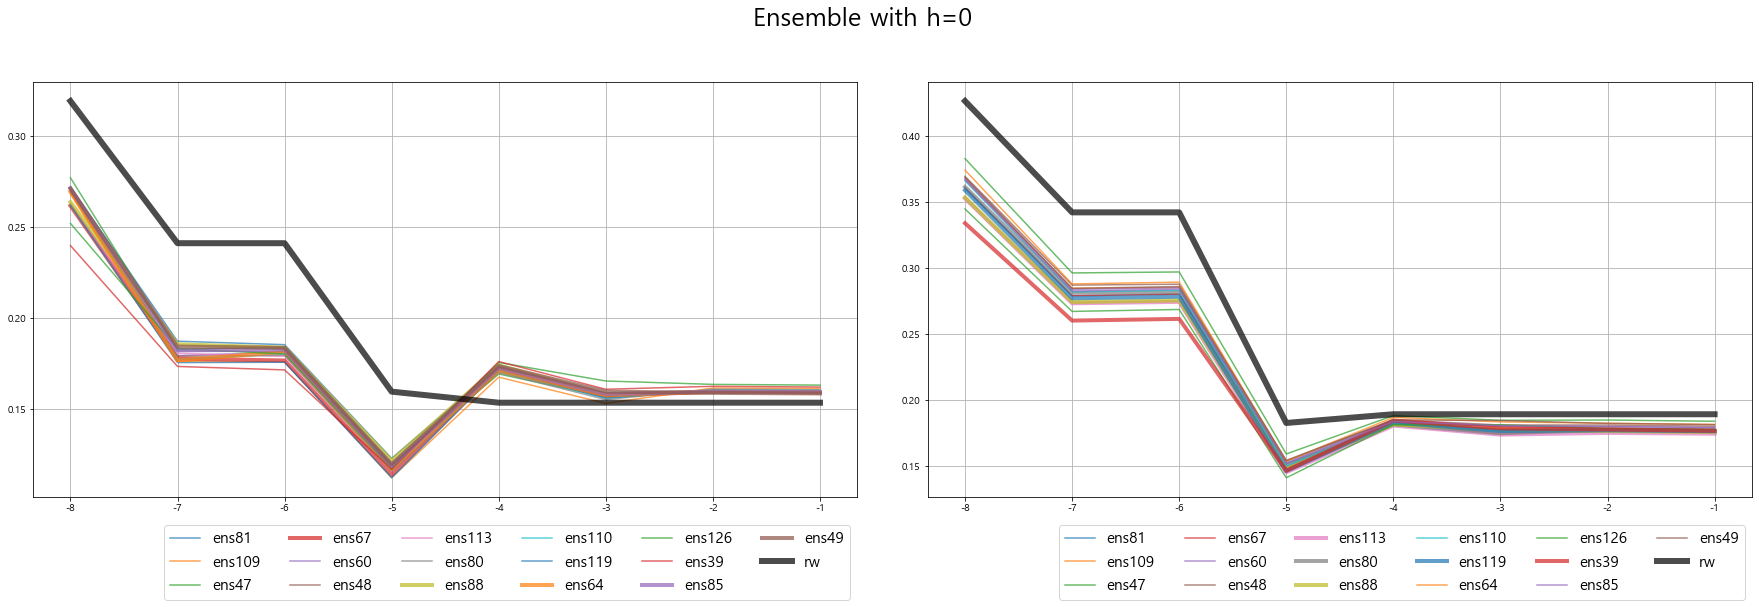

In [79]:
plot_mae_rmse(ens_mae, ens_rmse, rw_mae, rw_rmse, h=0, best=5, good=10, title='Ensemble',
              loc=1, ncol=6, figsize=(25, 8), fontsize=15, bbox_to_anchor=(1, -0.05))

In [84]:
#for i in [273, 685, 697, 541, 201, 695, 693, 217, 203]:
for i in [113, 88, 119, 80, 39]:
    print(i, '   '.join(ens_models[i]))

113 lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   ext_roll0_lag0_d6_g1_IN
88 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   ext_roll0_lag0_d6_g1_IN
119 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   ext_roll0_lag0_d6_g1_IN
80 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN   ext_roll0_lag0_d6_g1_IN
39 lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN   lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN   ext_roll0_lag0_d6_g1_IN


(MAE) ens94: 0.375 ens97: 0.382 ens111: 0.382 ens24: 0.382 ens112: 0.385 
(RMSE) ens97: 0.433 ens94: 0.439 ens101: 0.440 ens98: 0.443 ens111: 0.443 
rw mae: 0.486 rw rmse: 0.534


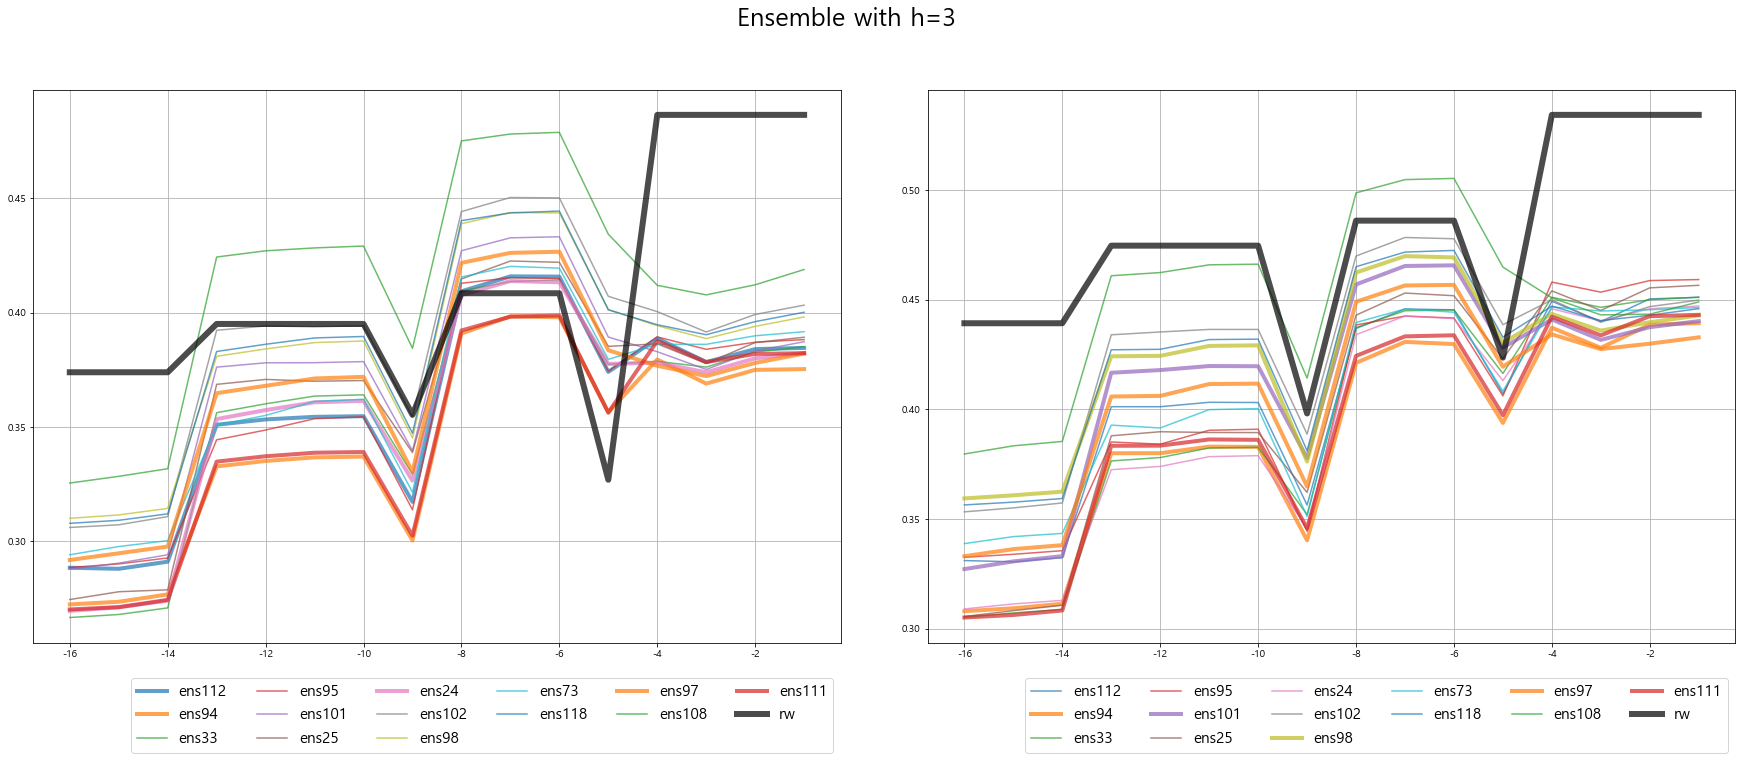

In [85]:
plot_mae_rmse(ens_mae, ens_rmse, rw_mae, rw_rmse, h=3, best=5, good=10, title='Ensemble',
              loc=1, ncol=6, figsize=(25, 10), fontsize=15, bbox_to_anchor=(1, -0.05), rw=True)

In [86]:
#for i in [113, 169, 17, 112, 168, 77, 372, 78, 374, 373]: # 324, 327, 1005, 326
for i in [97, 94, 101, 98, 111]:
    print( i, '    '.join(ens_models[i]))

97 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
94 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
101 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
98 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
111 lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN


(MAE) ens43: 0.209 ens23: 0.219 ens44: 0.220 ens8: 0.223 ens92: 0.244 
(RMSE) ens8: 0.262 ens6: 0.287 ens43: 0.290 ens23: 0.296 ens105: 0.305 
rw mae: 0.955 rw rmse: 0.960


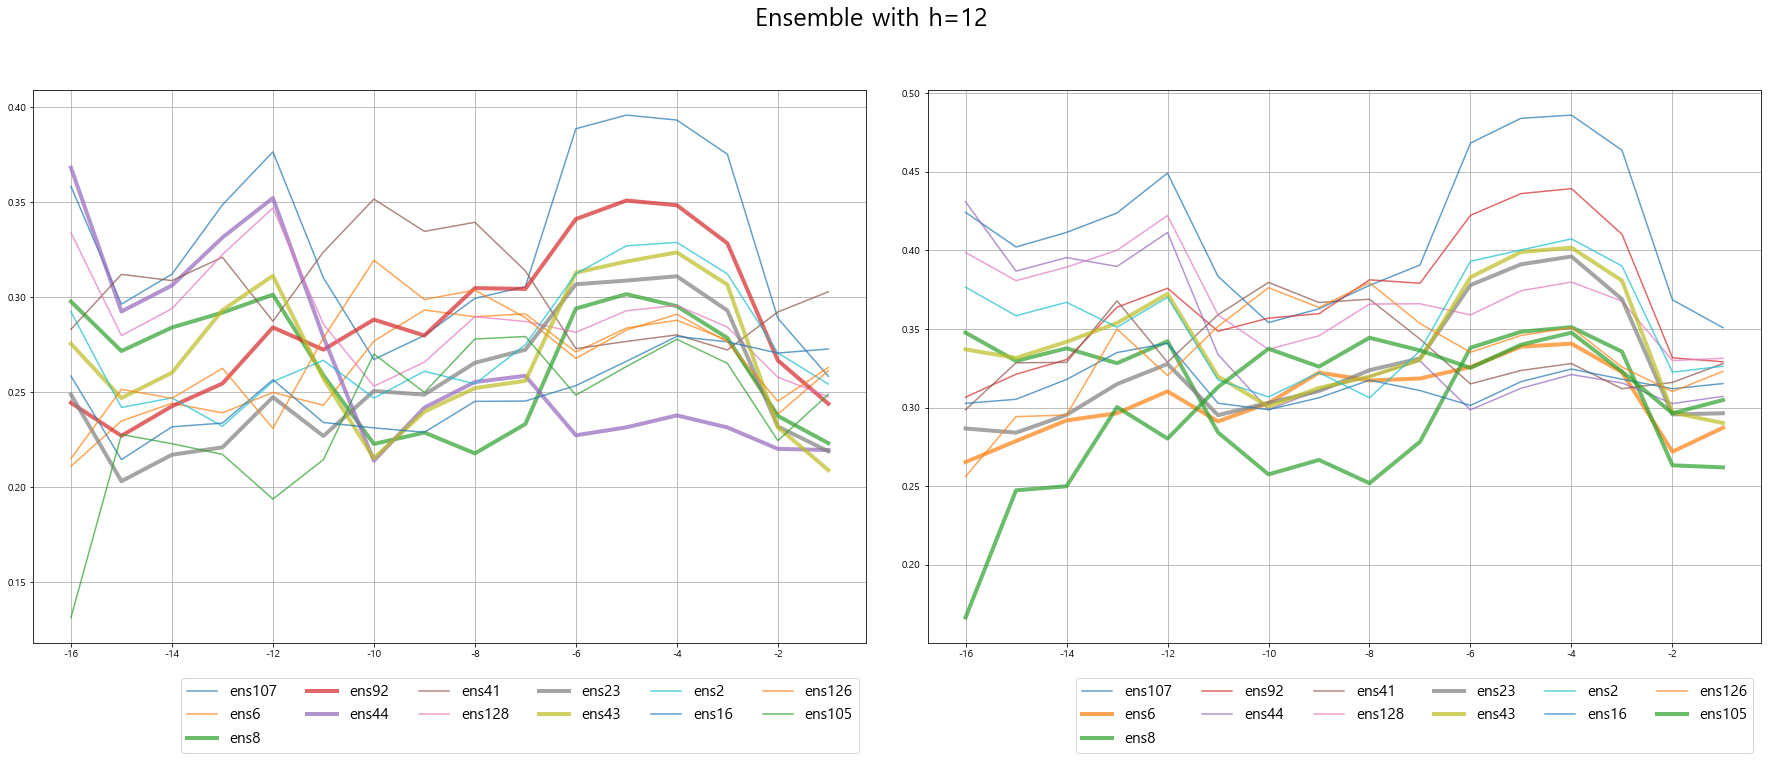

In [87]:
plot_mae_rmse(ens_mae, ens_rmse, rw_mae, rw_rmse, h=12, best=5, good=10, title='Ensemble',
              loc=1, ncol=6, figsize=(25, 10), fontsize=15, bbox_to_anchor=(1, -0.05), rw=False)

In [89]:
#for i in [21, 4, 5, 6, 7, 22]: # 8, 11, 9, 10,
for i in [8, 6, 4, 3, 23, 105]:
    print(i, '    '.join(ens_models[i]))

8 lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
6 lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
4 lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
3 lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
23 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
105 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN


In [90]:
#ens_rmsef.iloc[:,-1].mean()/rw_rmse.iloc[:,-1].mean() #rmse ratio

# MDA

In [94]:
ens_pred = ens_pred.sort_index(axis=1)
lm_pred = lm_pred.sort_index(axis=1)
ext_pred = ext_pred.sort_index(axis=1)

In [ ]:
# tm16 = '2016-1-31'
# tm19 = '2019-1-31'
# tm20 = '2020-1-31'
# tm21 = '2021-1-31'
# tm22 = '2022-1-31'
# tm99 = '2023-9-30'

In [98]:
tm25 = '2025-1-31'

In [109]:
act.loc[rw_pred_last.index]

2025-01-31    2.244411
2025-02-28    2.021445
2025-03-31    2.053532
2025-04-30    2.078765
2025-05-31    1.901840
Name: P_cpi_1, dtype: float64

In [127]:
#for h in [0, 3, 12]:
for h in [0]:
    matched, mda, mda, p1, p2 = get_mda(rw_pred_last.loc[tm25:, h], act, h, print_result=True)

mda: 0.00 (0/4), mda_big: 0.00 (0/2, 0.13) 


In [ ]:
#arima_models = ['arima_p2_q1_r3', 'arima_p3_q1_r3']
arima_models = ['arima_p3_q1_r3']
#for h in [0, 3, 12]:
for h in [0]:
    #mae, rmse, pred_last = get_eval_last_pred(arima_pred.loc[:, idx[arima_models, :, :tm25]], arima_models, act)
    mae, rmse, pred_last = get_eval_last_pred(arima_pred.loc[:, idx[arima_models, :, tm25:]], arima_models, act)
    best = mae[h].loc[-1].sort_values().iloc[:1].index.tolist()
    best += rmse[h].loc[-1].sort_values().iloc[:1].index.tolist()
    best = list(set(best))
    for i in best:
        matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=True)

  0%|          | 0/1 [00:00<?, ?it/s]

mda: 0.75 (3/4), mda_big: 1.00 (2/2, 0.13) arima_p3_q1_r3


In [ ]:
arima_models = ['arima_p2_q1_r3', 'arima_p3_q1_r3']
for h in [0, 3, 12]:
    mae, rmse, pred_last = get_eval_last_pred(arima_pred.loc[:, idx[arima_models, :, tm21:tm99]], arima_models, act)
    best = mae[h].loc[-1].sort_values().iloc[:1].index.tolist()
    best += rmse[h].loc[-1].sort_values().iloc[:1].index.tolist()
    best = list(set(best))
    for i in best:
        matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=True)

  0%|          | 0/2 [00:00<?, ?it/s]

mda: 0.69 (22/32), mda_big: 0.60 (9/15, 0.46) arima_p2_q1_r3


  0%|          | 0/2 [00:00<?, ?it/s]

mda: 0.72 (21/29), mda_big: 0.89 (8/9, 1.18) arima_p2_q1_r3


  0%|          | 0/2 [00:00<?, ?it/s]

mda: 0.65 (13/20), mda_big: 0.67 (8/12, 2.33) arima_p2_q1_r3
mda: 0.35 (7/20), mda_big: 0.33 (4/12, 2.33) arima_p3_q1_r3


## h = 0

In [139]:
ens_mae[0].loc[-1].sort_values().iloc[:10].index.tolist()

['ens49',
 'ens67',
 'ens64',
 'ens88',
 'ens85',
 'ens60',
 'ens81',
 'ens48',
 'ens47',
 'ens119']

In [141]:
models = ['ens' + str(i) for i in [49, 67, 64, 88, 85, 60, 81, 48, 47, 119]]

for i in [int(m[3:]) for m in models]:
   print(i, '    '.join(ens_models[i]))

49 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
67 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
64 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
88 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
85 lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN
60 lm_roll0_lag3_mod

In [143]:
models = ['ens' + str(i) for i in [49]]

for i in [int(m[3:]) for m in models]:
    print(i, '    '.join(ens_models[i]))

49 lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN


In [144]:
h=0
# M0 = tm16
# M1 = tm21
M0 = tm25
M1 = '2025-05-31'
topN = 10

mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")


mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# M0 = tm21
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")
# M0 = tm16
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

  0%|          | 0/1 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.159, rmse: 0.181 mda: 0.50 (2/4) mda_big: 1.00 (2/2, 0.13) model: ens49


  0%|          | 0/9 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.158, rmse: 0.184 mda: 0.50 (2/4) mda_big: 1.00 (2/2, 0.13) model: lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.154, rmse: 0.178 mda: 0.50 (2/4) mda_big: 1.00 (2/2, 0.13) model: lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.170, rmse: 0.201 mda: 0.50 (2/4) mda_big: 1.00 (2/2, 0.13) model: lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.154, rmse: 0.170 mda: 0.50 (2/4) mda_big: 1.00 (2/2, 0.13) model: lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 0.153, rmse: 0.178 mda: 0.25 (1/4) mda_big: 0.50 (1/2, 0.13) model: lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 0.153, rmse: 0.170 mda: 0.50 (2/4) mda_big: 1.00 (2/2, 0.13) model: lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 0.149, rmse: 0.167 mda: 0.50 (2/4) mda_big: 1.00 (2/2, 0.13) model: lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.167, rmse: 0.192 mda: 0.50 (2/4) mda_big: 1.00 (2/2, 0.13) model: lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB

## h = 3

In [201]:
ens_mae[3].loc[-1].sort_values().iloc[:10].index.tolist()

['ens94',
 'ens97',
 'ens111',
 'ens24',
 'ens112',
 'ens33',
 'ens101',
 'ens95',
 'ens25',
 'ens73']

In [202]:
ens_models[94]

['lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN',
 'ext_roll0_lag0_d6_g1_IN']

In [203]:
models = ['ens' + str(i) for i in [94]]

for i in [int(m[3:]) for m in models]:
    print(i, '    '.join(ens_models[i]))

94 lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN


In [204]:
mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)

  0%|          | 0/1 [00:00<?, ?it/s]

In [209]:
h=3
# M0 = tm16
# M1 = tm21
M0 = tm25
M1 = '2025-05-31'
topN = 10

mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# M0 = tm21
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# M0 = tm16
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

  0%|          | 0/1 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.375, rmse: 0.439 mda: 0.75 (3/4) mda_big: 1.00 (2/2, 0.45) model: ens94


  0%|          | 0/9 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.450, rmse: 0.502 mda: 0.50 (2/4) mda_big: 0.50 (1/2, 0.45) model: lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.420, rmse: 0.458 mda: 0.50 (2/4) mda_big: 0.50 (1/2, 0.45) model: lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.373, rmse: 0.391 mda: 0.75 (3/4) mda_big: 1.00 (2/2, 0.45) model: lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.377, rmse: 0.400 mda: 0.75 (3/4) mda_big: 1.00 (2/2, 0.45) model: lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 0.412, rmse: 0.437 mda: 0.75 (3/4) mda_big: 1.00 (2/2, 0.45) model: lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 0.457, rmse: 0.504 mda: 0.75 (3/4) mda_big: 1.00 (2/2, 0.45) model: lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 0.465, rmse: 0.506 mda: 0.50 (2/4) mda_big: 0.50 (1/2, 0.45) model: lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.381, rmse: 0.407 mda: 0.50 (2/4) mda_big: 0.50 (1/2, 0.45) model: lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB

## h = 12

In [210]:
ens_mae[12].loc[-1].sort_values().iloc[:10].index.tolist()

['ens43',
 'ens23',
 'ens44',
 'ens8',
 'ens92',
 'ens128',
 'ens105',
 'ens2',
 'ens107',
 'ens6']

In [211]:
ens_models[43]

['lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN',
 'ext_roll0_lag0_d6_g1_IN']

In [212]:
models = ['ens' + str(i) for i in [43]]

for i in [int(m[3:]) for m in models]:
    print(i, '    '.join(ens_models[i]))

43 lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN    lm_roll0_lag6_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN    ext_roll0_lag0_d6_g1_IN


In [213]:
h=12
# M0 = tm16
# M1 = tm21
M0 = tm25
M1 = '2025-05-31'
topN = 10

mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
best = list(set(best))
print(f"{M0} - {M1}")
for i in best:
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
    print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# M0 = tm21
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:topN].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")
# M0 = tm16
# M1 = tm99
# mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[models, :, M0:M1]], models, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

# mae, rmse, pred_last = get_eval_last_pred(lm_pred.loc[:, idx[lm_best_for_ensemble, :, M0:M1]], lm_best_for_ensemble, act)
# best = mae[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best += rmse[h].loc[-1].sort_values().iloc[:5].index.tolist()
# best = list(set(best))
# print(f"{M0} - {M1}")
# for i in best:
#     matched, mda, mda, p1, p2 = get_mda(pred_last[h][i], act, h, model=i, print_result=False)
#     print(f"mae: {mae[h][i].iloc[-1]:.3f}, rmse: {rmse[h][i].iloc[-1]:.3f}", p1, p2, f"model: {i}")

  0%|          | 0/1 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.209, rmse: 0.290 mda: 1.00 (4/4) mda_big: 1.00 (4/4, 0.11) model: ens43


  0%|          | 0/9 [00:00<?, ?it/s]

2025-1-31 - 2025-05-31
mae: 0.671, rmse: 0.775 mda: 0.75 (3/4) mda_big: 0.75 (3/4, 0.11) model: lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.509, rmse: 0.613 mda: 0.75 (3/4) mda_big: 0.75 (3/4, 0.11) model: lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.441, rmse: 0.547 mda: 1.00 (4/4) mda_big: 1.00 (4/4, 0.11) model: lm_roll0_lag4_modelRE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 1.150, rmse: 1.152 mda: 0.25 (1/4) mda_big: 0.25 (1/4, 0.11) model: lm_roll0_lag4_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 1.064, rmse: 1.066 mda: 0.25 (1/4) mda_big: 0.25 (1/4, 0.11) model: lm_roll0_lag3_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 1.137, rmse: 1.149 mda: 0.50 (2/4) mda_big: 0.50 (2/4, 0.11) model: lm_roll0_lag6_modelP_ipi_6-P_cpi_1-GB_cp_3_IN
mae: 0.332, rmse: 0.431 mda: 1.00 (4/4) mda_big: 1.00 (4/4, 0.11) model: lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN
mae: 0.492, rmse: 0.536 mda: 1.00 (4/4) mda_big: 1.00 (4/4, 0.11) model: lm_roll0_lag3_modelRE_atpi_1-P_cpi_1-GB

## MDA plot

In [214]:
MATCHED = {}

# M0 = tm16
# M1 = tm99
M0 = tm25
M1 = '2025-05-31'

for h, model in zip([0, 3, 12], ['ens49', 'ens94', 'ens43']):
    mae, rmse, pred_last = get_eval_last_pred(ens_pred.loc[:, idx[[model], :, M0:M1]], [model], act)
    matched, mda, mda, p1, p2 = get_mda(pred_last[h][model], act, h, model=model, print_result=False)

    df = matched.to_frame('m')
    df['i'] = 0
    df.loc[df.m.eq(False), 'i'] = 1
    df['c'] = df['i'].cumsum()
    df = df.loc[df.m == True]
    df['date'] = df.index
    df = pd.concat([df.groupby('c')['date'].first().to_frame('first'), df.groupby('c')['date'].last().to_frame('last')], axis=1)
    df.index.names = [None]
    MATCHED[h] = df

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

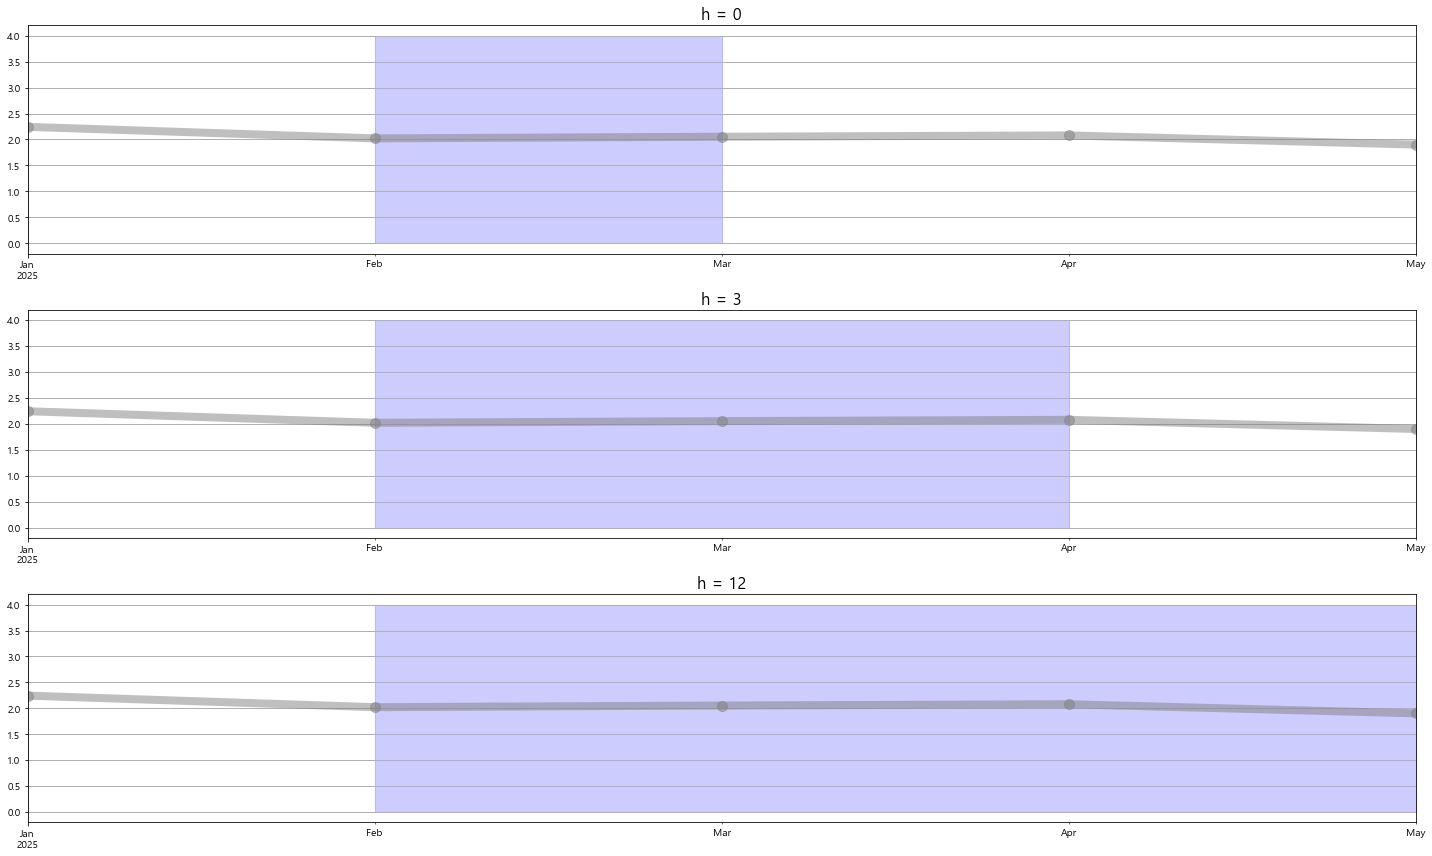

In [252]:
fig, axs = plt.subplots(3, 1, figsize=(20, 12))
for ax, h in zip(axs, [0, 3, 12]):
    act[targets].loc['2025':].plot(ax=ax, lw=8, color='gray', marker='o', markersize=10, alpha=0.5)
    ax.grid(which='major', lw=1)
    #ax.legend(fontsize=14)
    ax.set_title(f"h = {h}", fontsize=16)

    for ix, row in MATCHED[h].iterrows(): # iterrows: 행 인덱스와 행 데이터를 모두 반환
        m0 = row['first']
        m1 = row['last'] + MonthEnd(1)
        #m0 = nth_friday(m0.year, m0.month, -2)
        #m1 = nth_friday(m1.year, m1.month, 2)
        ax.fill_between(pd.date_range(m0, m1), 4, color='blue', alpha=.2)

fig.tight_layout()

# 실제치

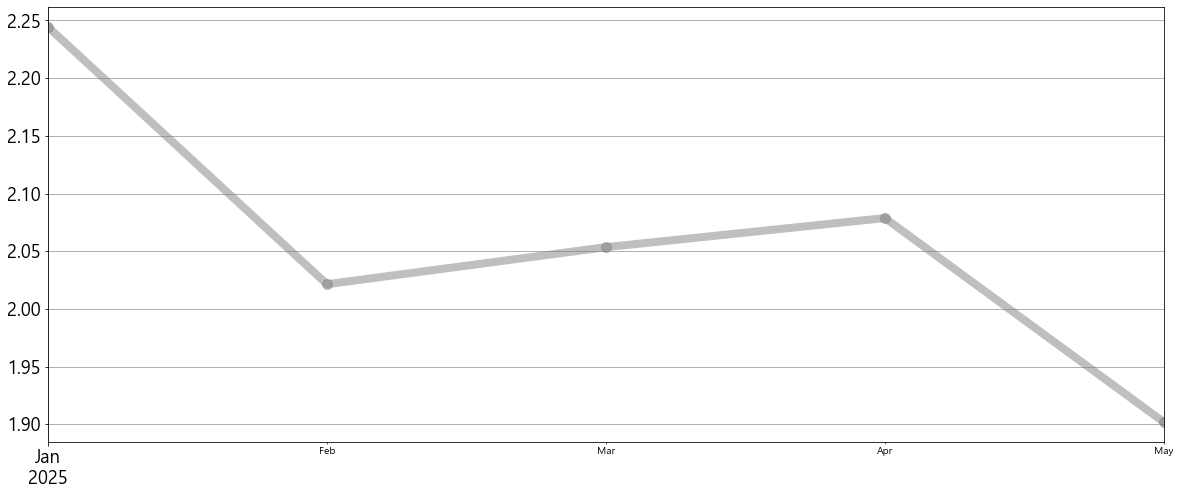

In [253]:
fig, axs = plt.subplots(1, 1, figsize=(20, 8))
for ax, h in zip([axs], [0]):
    act[targets].loc['2017':].plot(ax=ax, lw=8, color='gray', marker='o', markersize=10, alpha=0.5)
    #ax.grid(which='minor', lw=1)
    ax.grid(which='major', lw=1)
    #ax.legend(fontsize=14)
    #ax.set_title(f"h = {h}", fontsize=16)
    ax.tick_params(axis="both", labelsize=18)
    for x in ['2018-11-30', '2020-10-31', '2022-07-31']:
        ax.axvline(x=x, lw=6, color='y', alpha=0.5)

# 전망시계별 전망모형

In [258]:
ens_sel = {0:49, 3:94, 12:43}

## 기여도분해

In [ ]:
fms = [pd.Timestamp(date+'-1') for date # data + '-1' = 2025-06-1 -> 2025-06-01 파싱
       #in ['2020-10', '2022-7', '2023-7', '2023-8', '2023-9', '2023-10', '2023-11']]
       in ['2025-1']]

In [280]:
#[month + MonthEnd(0) for month in pd.date_range('2023-8-1', '2023-9-1', freq='M')]
#for month in pd.date_range('2023-8-1', '2023-9-1', freq='M'):
for month in fms:

    fm = month + MonthEnd(0)

    today = nth_friday(fm.year, fm.month, 1)
    _, act_vintage = get_train_data_v5(DF_vintages[today])
    last_inf_month = act_vintage.dropna().index[-1]
    last_inf = act_vintage.dropna().iloc[-1]
    #print(f"The latest inflation is {last_inf:.2f} for {last_inf_month:%Y-%m}")

    for h in [0, 3, 12]:

        tm = fm + MonthEnd(h)
        model_names = ens_models[ens_sel[h]]
        print(f"\nhor : {h} months, fm : {fm:%Y-%m}, tm : {tm:%Y-%m}")
        print(', '.join(model_names))

        PRED_DECOMP = pd.DataFrame()

        for mname in model_names: # 앙상블 구성 모형별 반복
            mname = mname.split('_IN')[0]
            print(f"\ndecomposing {mname} ...")
            try:
                model = joblib.load(f"model/{mname}_{tm.year}-01_h{h}.pkl")
            except:
                print(f"Model for {tm.year - 1} is loaded instead of {tm.year}, which does NOT exist.")
                model = joblib.load(f"model/{mname}_{tm.year - 1}-01_h{h}.pkl")

            fm_vintages = [date for date in vintages if (date.month == fm.month) and (date.year == fm.year)]

            if h == 0:
                pm = fm - MonthEnd(1)
                pm_vintages = [nth_friday(pm.year, pm.month, i) for i in [-3, -2, -1]] # 3, 2, 1주 전 금요일
            else:
                pm_vintages = [nth_friday(m.year, m.month, -1) for m in [fm - MonthEnd(i) for i in [3, 2, 1]]] # 3, 2, 1 개월 전 마지막 금요일

            decomp_vintages = pm_vintages + fm_vintages
            pred = pd.DataFrame(index=decomp_vintages, columns=['forecast'])

            rolling = int(mname.split('_roll')[1].split('_')[0])
            lag = int(mname.split('_lag')[1].split('_')[0])

            if mname.split('_')[0] == 'lm':
                data_group = mname.split('_model')[1].split('-')
                excl_alt = False
            else:
                data_group = int(mname.split('_g')[1].split('_')[0])
                excl_alt = True

            df0 = DF_vintages[decomp_vintages[0]].copy()
            X0, _ = get_train_data_v5(df0, lag, data_group, excl_alt, fm, rolling=rolling)

            if mname.split('_')[0] == 'lm':
                pred0 = model.predict(X0.loc[[fm]])[0]
            else:
                if h == 12:
                    X0 = X0.drop(['P_eir'], axis = 1) # 12개월 전망 기대인플레 제외
                else:
                    pass
                pred0 = model.predict(X0.loc[[fm]])[0] + last_inf

            decomp = pd.DataFrame(index=decomp_vintages[1:], columns=df0.columns)
            pred.loc[decomp_vintages[0], 'forecast'] = pred0

            for v in decomp_vintages[1:]:
                print(f"{v:%m-%d}", end=' ')
                df1 = DF_vintages[v].copy()

                for col in df0.columns:
                    df0 = df0.reindex(df1.index) # 인덱스 맞추기
                    df0.loc[:, col] = df1.loc[:, col].copy()
                    X1, _ = get_train_data_v5(df0, lag, data_group, excl_alt, fm, rolling=rolling)
                    if mname.split('_')[0] == 'lm':
                        pred1 = model.predict(X1.loc[[fm]])[0]
                    else:
                        if h == 12:
                            X1 = X1.drop(['P_eir'], axis = 1) # 12개월 전망 기대인플레 제외
                        else:
                            pass
                        pred1 = model.predict(X1.loc[[fm]])[0] + last_inf
                    diff = pred1 - pred0
                    if np.abs(diff) > 0.001:
                        print(f"({col}){diff:.3f}", end=' ')
                    decomp.loc[v, col] = diff
                    pred0 = pred1

                pred.loc[v, 'forecast'] = pred1
                print(f"({pred1:.3f})")

            decomp = decomp.applymap(lambda x: np.nan if np.abs(x) < 0.0001 else x)
            decomp = decomp.dropna(how='all', axis=1)
            pred_decomp = pd.concat([pred, decomp], axis=1)
            pred_decomp = pd.concat([pred_decomp], axis=1, keys=[mname])
            PRED_DECOMP = pd.concat([PRED_DECOMP, pred_decomp], axis=1)

        PRED_DECOMP.to_pickle(f"output/decomp_{fm:%Y-%m-%d}_{h}.pkl")


hor : 0 months, fm : 2025-01, tm : 2025-01
lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN, lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN, lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3_IN, ext_roll0_lag0_d6_g1_IN

decomposing lm_roll0_lag3_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3 ...
12-20 (GB_cp_3)0.005 (1.510)
12-27 (1.510)
01-03 (P_cpi_1)0.419 (GB_cp_3)-0.002 (1.926)
01-10 (GB_cp_3)-0.001 (1.925)
01-17 (P_ipi_6)0.037 (RE_atpi_1)-0.027 (GB_cp_3)-0.005 (1.931)
01-24 (1.931)
01-31 (GB_cp_3)0.001 (1.932)

decomposing lm_roll0_lag4_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3 ...
12-20 (RE_atpi_1)0.008 (GB_cp_3)0.004 (1.583)
12-27 (1.583)
01-03 (P_cpi_1)0.415 (GB_cp_3)-0.004 (1.994)
01-10 (GB_cp_3)-0.002 (1.992)
01-17 (P_ipi_6)0.042 (RE_atpi_1)-0.044 (GB_cp_3)-0.006 (1.984)
01-24 (1.984)
01-31 (GB_cp_3)0.002 (1.986)

decomposing lm_roll0_lag6_modelP_ipi_6-RE_atpi_1-P_cpi_1-GB_cp_3 ...
12-20 (RE_atpi_1)0.031 (GB_cp_3)0.003 (1.662)
12-27 (1.662)
01-03 (P_cpi_1)0.412 (GB_c

## 전망결과 차트



forecasting horizon: 0
12-20:	RE_atpi_1 (+0.010)   GB_cp_3   (+0.004)   P_ppi_35  (+0.000)   P_ppi_1   (+0.000)   LM_hl_5   (-0.000)   C_rsi_1   (+0.000)   EI_iai_1  (+0.000)   
12-27:	IE_mir_13 (+0.000)   GB_cp_3   (+0.000)   P_eir     (-0.000)   C_rsi_1   (+0.000)   EI_iai_1  (+0.000)   EI_ivi_1  (+0.000)   EI_tti_2  (+0.000)   
01-03:	P_cpi_1   (+0.311)   S_spi_1   (-0.010)   GB_cp_3   (-0.003)   IE_mir_8  (-0.001)   PB_ioi_1  (+0.001)   PB_ioi_3  (+0.001)   IE_mir_7  (+0.001)   
01-10:	GB_cp_3   (-0.001)   GB_chn_2  (-0.000)   C_rsi_1   (+0.000)   EI_iai_1  (+0.000)   EI_ivi_1  (+0.000)   EI_tti_2  (+0.000)   GB_us_1   (+0.000)   
01-17:	RE_atpi_1 (-0.031)   P_ipi_6   (+0.030)   GB_cp_3   (-0.006)   L_eap_7   (+0.003)   L_eap_10  (+0.001)   EI_iai_1  (+0.001)   EI_tti_2  (-0.000)   
01-24:	P_eir     (+0.000)   P_ppi_35  (-0.000)   GB_cp_3   (-0.000)   C_rsi_1   (+0.000)   EI_iai_1  (+0.000)   EI_ivi_1  (+0.000)   EI_tti_2  (+0.000)   
01-31:	GB_cp_3   (+0.002)   IE_mir_13 (+0.000

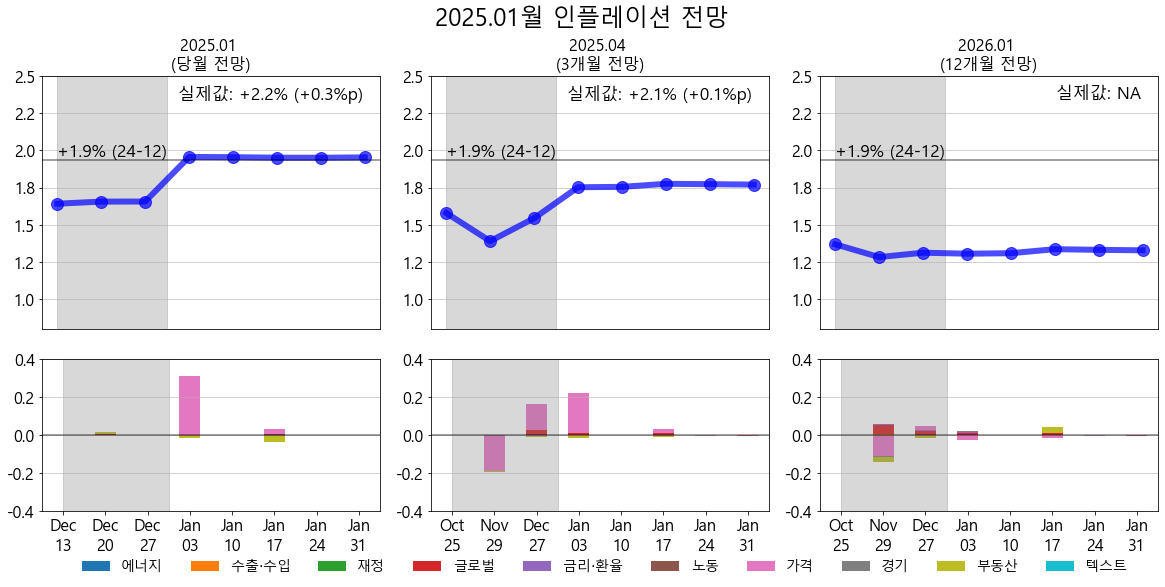

In [ ]:
fm = pd.Timestamp('2025-1-1') + MonthEnd()

fig, axs = plt.subplots(2, 3, figsize=(20, 8),
                        gridspec_kw={'width_ratios': [3, 3, 3], 'height_ratios': [5, 3],
                                     'wspace': 0.15, 'hspace': 0.15})
margin = 0.5
margin0 = 0.1

DECOMP_VAR = {}

vspec = pd.read_excel('input/data_list_all_v9.xlsx', index_col = None)
vspec.index.names = [None]
vspec['group'] = vspec['My ID'].str.split('_', expand=True)[0] # expand=True: 분할된 결과를 새로운 열로 추가
id_group = vspec[['My ID', 'group']].set_index('My ID').to_dict()['group'] # {id : group} 딕셔너리 만들기

_, act = get_train_data_v5(DF_vintages[vintages[-1]])
act = act.dropna()

pm = fm - MonthEnd(1)

ymax = act.loc[pm] # 예측치 차트 최대값
ymin = act.loc[pm] # 예측치 차트 최소값
dymax = 0 # 변동요인 차트 최대값
dymin = 0 # 변동요인 차트 최소값

for i, h in enumerate([0, 3, 12]):
    tm = fm + MonthEnd(h)

    PRED_DECOMP = pd.read_pickle(f"output/decomp_{fm:%Y-%m-%d}_{h}.pkl")
    pred_decomp_mean = PRED_DECOMP.groupby(level=1, axis=1).sum() # 모형별 decomp, forecast 결과를 sum
    pred_decomp_mean = (pred_decomp_mean / len(PRED_DECOMP.columns.get_level_values(0).unique()))
    DECOMP_VAR[h] = pred_decomp_mean
    decomp = pred_decomp_mean.rename(columns=id_group) # {id : group} 딕셔너리로 변수명을 그룹명으로 바꾸기
    decomp = decomp.groupby(decomp.columns, axis=1).sum() # 그룹별 sum

    today = decomp.index[-1]
    _, act_vintage = get_train_data_v5(DF_vintages[today])
    last_inf = act_vintage.dropna().iloc[-1]

    forecast = decomp.pop('forecast') # pop 열 추출하고 삭제
    decomp = decomp.reindex(columns=vspec.group.unique())
    decomp = decomp.rename(columns={'LM':'IE', 'S':'RE', 'C':'PB'}) # 그룹 합치기
    decomp = decomp.groupby(decomp.columns, axis=1).sum()
    decomp = decomp.rename(columns={'EG':'에너지', 'EI':r'수출$\cdot$수입', 'F':'재정', 'GB':'글로벌',
                                    'IE':r'금리$\cdot$환율', 'L':'노동', 'P':'가격', 'PB':'경기', 'RE':'부동산','T':'텍스트'})

    #diff = forecast - last_inf
    #diff = diff.to_frame('change w.r.t. last infl.')
    df = pd.concat([forecast, decomp], axis=1)
    df = df.reindex(sorted(list(set(df.index.tolist() + [nth_friday(fm.year, fm.month, i) for i in [-4, -3, -2, -1]]))))
    ticklabels = [t.strftime("%b\n%d") for t in df.index]
    df.index = np.arange(len(df.index)) # arrange: 인덱스를 0부터 시작하는 정수 배열로 변환

    df['forecast'].plot(ax=axs[0, i], lw=6, marker="o", color='b', markersize=12, alpha=0.7)
    #axs[0, i].plot(df.index, df.fillna(df.mean())['forecast'], alpha=0, color='b')
    #axs[0, i].plot(ticklabels, df.iloc[:, 0], lw=4, marker="o", markersize=12)
    df.iloc[:, 1:].plot.bar(stacked=True, ax=axs[1, i]) # 변동요인 바차트
    #axs[1, i].plot(df.index, df.fillna(df.mean())['forecast'], alpha=0, color='b')
    axs[1, i].set_xticklabels(ticklabels, rotation=0)
    
    axs[0, i].yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f')) # y축 소수점 1자리까지만 표시
    axs[1, i].yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    
    axs[0, i].axhline(y=last_inf, lw=1.5, color='k', alpha=0.5) # 마지막 인플레이션 수평선
    axs[1, i].axhline(y=0, lw=1.5, color='k', alpha=0.5) # 0 수평선
    ymin = min(df.iloc[:, 0].min(), ymin) # 최소값 업데이트
    ymax = max(df.iloc[:, 0].max(), ymax) # 최대값 업데이트
    dymax = max(np.abs(df.iloc[:, 1:]).sum(axis=1).max(), dymax) # 변동요인 y축 최대값 업데이트
    axs[1, i].legend(ncol=14, loc=3, frameon=False, bbox_to_anchor=(0.08, -0.5), fontsize=14)
    axs[0, i].grid(alpha=0.7, axis='y')
    axs[1, i].grid(alpha=0.7, axis='y')
    if h == 0:
        axs[0, i].set_title(f"{tm:%Y.%m} \n(당월 전망)", fontsize=16)
    else:
        axs[0, i].set_title(f"{tm:%Y.%m} \n({h}개월 전망)", fontsize=16)
    axs[0, i].tick_params(axis="both", labelsize=16)
    axs[1, i].tick_params(axis="both", labelsize=16)
    axs[0, i].get_xaxis().set_visible(False) # 상단 차트 tick 숨기기
    axs[0, i].text(0.0, last_inf, f"{act.loc[pm]:+.1f}% ({pm:%y-%m})", fontsize=17,
                       horizontalalignment='left', verticalalignment='bottom') # 마지막 인플레이션 텍스트로 넣기
    if i > 0:
        axs[1, i].get_legend().remove() # 변수별 그룹 범례 중복 방지
    try:
        axs[0, i].text(0.95, 0.93, f"실제값: {act.loc[tm]:+.1f}% ({act.loc[tm]-act.loc[pm]:+.1f}%p)", fontsize=17,
                       horizontalalignment='right', verticalalignment='center', transform=axs[0, i].transAxes)
    except:
        axs[0, i].text(0.95, 0.93, f"실제값: NA", fontsize=17,
                       horizontalalignment='right', verticalalignment='center', transform=axs[0, i].transAxes)

    axs[0, i].fill_between((0, 2.5), -10, 10, color='gray', alpha=.3) # 해당월 이전은 음영 처리
    axs[1, i].fill_between((0, 2.5), -10, 10, color='gray', alpha=.3) # -10~10 음영 처리

for i, h in enumerate([0, 3, 12]):
    axs[0, i].set_ylim(round(ymin - margin, 1), round(ymax + margin, 1)) # 예측치 차트 y축 범위
    axs[1, i].set_ylim(round(-dymax - margin0, 1), round(dymax + margin0, 1)) # 변동요인 차트 y축 범위

fig.suptitle(f"{fm:%Y.%m}월 인플레이션 전망", fontsize=24, y=1.0)   
    
text = ''
for h in [0, 3, 12]:
    text += f"\n\nh {h} "
    print(f"\n\nforecasting horizon: {h}", end='')
    dcomp = DECOMP_VAR[h].drop('forecast', axis=1)
    for i in dcomp.index[1:]:
        vars = np.abs(dcomp).loc[i].nlargest(7).index # 빈티지별 절대값 기준 상위 7개 변수
        text += f"\n{i:%m-%d}:\t"
        print(f"\n{i:%m-%d}:", end='\t')
        for v in vars:
            text += f"{v:<10}({dcomp.loc[i, v]:+.3f})    "
            print(f"{v:<10}({dcomp.loc[i, v]:+.3f})", end='   ')

fig.patch.set_alpha(0.0)